<h2>B-Tree Code</h2>
In this lab, we have supplied the code for B-Tree and a brief description of how to implement the various operations. The exposition below follows this very nice survey: <a href="https://dl.acm.org/doi/pdf/10.1145/356770.356776">Ubiquitous B-Tree</a>
Please take a look at the survey -- it does an excellent job of explaining the techniques at a high level with examples.
<p />
Warning: This is an "advanced" data structure. The implementation is going to be longer than usual. We suggest however that you examine the notes in detail. The upcoming problem set will require it.
<p />
We have built in three stages:
<ul>
<li>BTreeBaseNode : implements all the necessary fields that one needs in a BTree node and some important utility functions.</li>
<li>BTreeWithNodeInsert : implements the function to insert a key into the BTree.</li>
<li>BTreeNode: adds the function to delete a key on top of BTreeWithInsert</li>
</ul>

<h2> Structure of BTree Node</h2>
Each BTree node will have the following fields:
<ul>
<li>d: the value of parameter d for the B-Tree</li>
<li>keys: list of keys that are sorted in ascending order. The length of keys must be between 0 and 2d for the root noce and between d and 2d for the other nodes</li>
<li>pointers: list of pointers to child nodes.
<ul><li>If the node is a leaf, then  length of pointers wil be 0</li><li>If the ndoe is not a leaf, the length of pointers will be one more than the length of keys</li></ul>
<li>is_root : Boolean indicating if the node is a root</li>
<li>parent: for a root ndoe this will be None, otherwise, it will be tuple form (parent_node, parent_idx), wherein parent_node is the pointer to nodes parent. parent_idx is the index of curent node in the list parent_node.pointers. In other words parent_node.pointers[parent_idx} == self</li>
<li> For a key keys[i] its left child is at poitners[i] whuch will point to a node whose keys are < keys[i]. Its right child is at pointers[i+1] which will point to a node whose keys are > keys[i] (but less than keys[i+1] if that exists)</li>
</ul>




<h4> Implementing Find</h4>
We have an implementation of the find function for B-Tree which uses the find_key_internal function. The find_key_internal method seeks to find the node that contains a key and the index into the nodes, or return None if the key is not part of the tree.
(1)Starting from the root, it searches for the kay at current node. If the key is found, it returns immediately
(2)Otherwise, it fetches the child node whose subtree will contain the key if it is in the tree, and recursively calls find_key_itnernal on the child node

<h4>Inserting a Key into the BTree</h4>
We will implement the insert function that insert a key new_key into the tree. The key logic is implemented in the insert_helper function.
We will assume that the key to be inserted is not part of the tree though this is also handled in our implementation. Note that in a search tree, a key can appear at most once in the tree.

The insert_helper function has two phases:

<ul><li>First, it descends from the root to the leaf as if trying to search for the new_key that we wish to insert.</li>
<li>Next, it inserts the new_key at the leaf first and ascends back up to the root to try and fix nodes that may have become full as a result of the insertion.</li>
</ul>

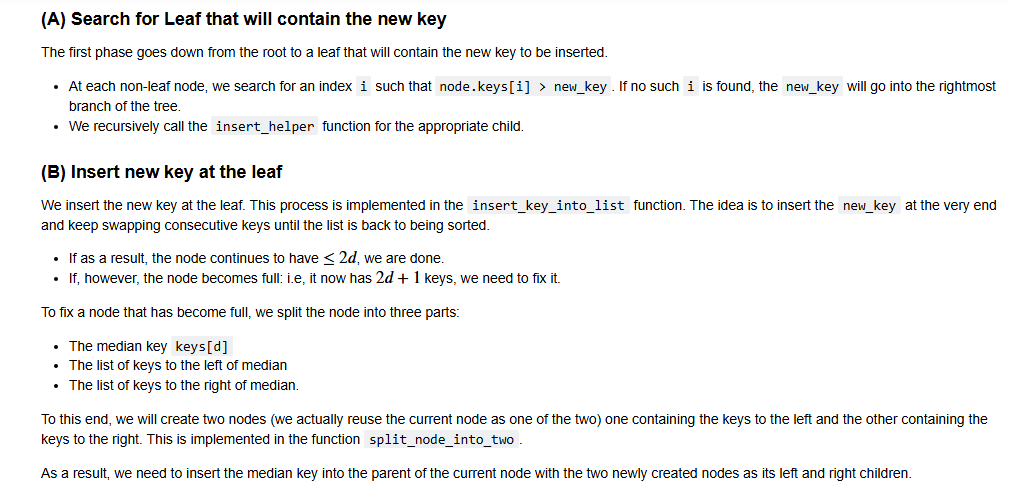

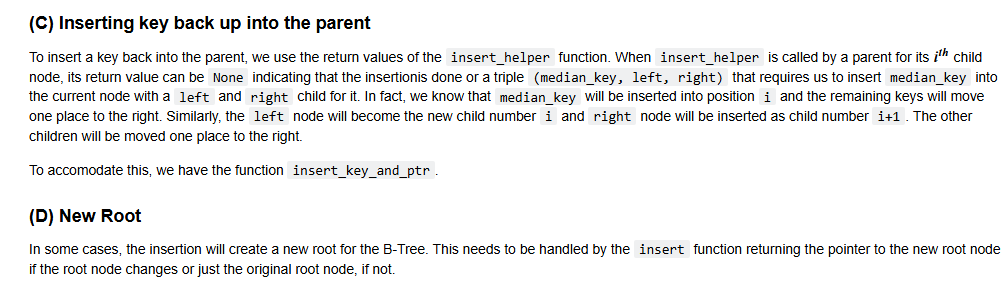


In [ ]:
class BTreeNodeBase: # this class is not completely coded
    def __init__(self, keys, ptrs, is_root, d):
        self.keys = keys
        self.pointers = ptrs
        
        self.is_root = is_root
        if is_root:
            self.parent = None
        self.d = d

    def is_leaf(self):
        return len(self.pointers)==0
    
    def set_parent(self,new_root, idx):
        self.parent = (new_root, idx)
        # self.parent[0][idx] = self
        # assert len(self.pointers) == len(self.keys)+1
    
    def check_root_node(self):
        m = len(self.keys)
        if m<0 or m>(2*self.d):
            return False
        return True    
    
    def check_internal_node(self):
        m = len(self.keys)
        if m<self.d or m>(2*self.d):
            return False
        return True
    
    def check_leaf_node(self):
        num_children = len(self.pointers)
        num_keys = len(self.keys)
        if num_keys<self.d or num_keys>(2*self.d) or num_children>0:
            return False
        
        return True
    
    def rep_ok(self):
        
        if self.is_leaf() :
            return self.check_leaf_node()
        
        if self.is_root:
            return self.check_root_node()

        if not self.is_leaf and not self.is_root:
            return self.check_internal_node()
        
class BTreeNodeWithInsert(BTreeNodeBase): # BTreeNodeBase is passed for inheritence
    
    def __init__(self, keys = [], ptrs = [], is_root=False, d = 10):
        super().__init__(keys, ptrs, is_root, d)
        
    def create_new_instance(self, keys, ptrs, is_root, d):
        """We need this to construct a new instance because we chose to split the implementation across three different classes"""
        return BTreeNodeWithInsert(keys, ptrs, is_root, d)
    
        
    def insert(self, new_key):
        """Insert a key new_key into the tree. 
           Call this only when self is the root node"""
        assert self.is_root
        res = self.insert_helper(new_key) # the helper function has the logic for insertion
        if res != None: 
            (mid_key, n1, n2) = res # if the helper function returns a triple mid_key and two new nodes
            self.is_root = False  # we need to create a new root
            new_root = self.create_new_instance( [mid_key], [n1, n2], True, self.d) # create new root with a single key and two children
            n1.set_parent(new_root, 0) # set the parent pointers for n1, n2
            n2.set_parent(new_root, 1)
            return new_root  # return the new_root
        else:
            return self # Otherwise, the root node is unchanged
    
    def insert_helper(self, new_key, debug=True):
        """ This is a helper function for inserting a new key new_key into a node. 
        It returns either None which means that there was space for the key 
        or a triple (mid_key, n1, n2) to be inserted up into the parent node."""
        # if the node is a leaf
        if self.is_leaf(): 
            self.insert_key_into_list(new_key) # insert the key into the list
            n = len(self.keys)  # count the number of keys
            if n <= 2* self.d:  # node size is acceptable
                return None       # we are done, return None
            else:
                # node is full, we need to split 
                assert n == 2 * self.d + 1 # Node just became full as a result of this new insertion
                (mid_key, n1, n2) = self.split_node_into_two() # split it into two nodes
                return (mid_key, n1,  n2) # return the two nodes and middle key
        else:
            # find first index i such that self.keys[i] >= k
            i = 0
            n = len(self.keys)
            while i < n and self.keys[i] < new_key:
                i = i + 1
            # We should not find a copy of the key 
            if  i < n and self.keys[i] == new_key:
                if debug:
                    print(f'Key {k} already exists') # this is bad but ignore for now
                return None           
            else:
                res = self.pointers[i].insert_helper(new_key) # insert into the child
                if res != None:
                    (mid_key, node_left, node_right) = res # unpack
                    # insert the new key coming up from the child into self along with the two pointers
                    self.insert_key_and_ptr(mid_key, node_left, node_right, i)
                    # did the node become full as a result of the insertion?
                    if len(self.keys) == 2 * self.d+1:
                        (mid_key, n1, n2) = self.split_node_into_two() # split myself into two
                        return (mid_key, n1, n2) # return the median key and two nodes back to my caller
                 
            
    def insert_key_into_list(self, new_key):
        """Insert new_key into the list for this node. Call this function only on leaf nodes"""
        assert self.is_leaf()
        n = len(self.keys)
        assert new_key not in self.keys, f'key {new_key} already exists {self.keys}'
        self.keys.append(new_key)
        i = n
        while i >= 1 and self.keys[i] < self.keys[i-1]:
            # swap
            (self.keys[i-1], self.keys[i]) =  (self.keys[i], self.keys[i-1])
            i = i-1
            
    def insert_key_and_ptr(self, mid_key, node_left, node_right, i):
        """Insert the new_key into the list at position i. 
           Make sure that its left child is 
           node_left and right child is node_right. """
        n = len(self.keys)
        assert i >= 0 and i <= n
        node_left.set_parent(self, i)
        #assert self.keys[i] > mid_key
        assert self.pointers[i] == node_left 
        (new_key, new_child) = (mid_key, node_right)
        for j in range(i, n):
            (self.keys[j], new_key) = (new_key, self.keys[j])
            (self.pointers[j+1], new_child) = (new_child, self.pointers[j+1])
            self.pointers[j+1].set_parent(self, j+1) # fix the parent pointer since the child node position changes
        self.keys.append(new_key)
        self.pointers.append(new_child)
        new_child.set_parent(self, n+1)
        
    def fix_parent_pointers_for_children(self):
        for (j, child_node) in enumerate(self.pointers):
            child_node.set_parent(self, j)
        
    def split_node_into_two(self):
        """Split a node into two along the median. Call only if the node is full"""
        assert len(self.keys) == 2 * self.d + 1 # node is full
        n = len(self.keys)
        d = self.d
        med_key = self.keys[d]
        new_keys = list(self.keys[d+1:]) # take all keys past position d + 1
        self.keys = list(self.keys[:d])
        if self.is_leaf():
            new_ptrs = []
        else:
            new_ptrs = list(self.pointers[d+1:])
            self.pointers = list(self.pointers[:d+1])
        new_node = self.create_new_instance(new_keys, new_ptrs, False, d) # create a new node 
        new_node.fix_parent_pointers_for_children() # make sure that for the new node, we fix the parent pointers for children to now point to the new node 
        return (med_key, self, new_node) ## return a triple of things to insert
        
    
       
    
        
   
        

In [28]:
%matplotlib inline
import networkx as nx 
from matplotlib import pyplot as plt 

def draw_btree_graph(n):
    G = nx.DiGraph()
    labels = {}
    n.make_networkx_graph(G, 0, -1, labels)
    pos = nx.nx_agraph.graphviz_layout(G, prog="dot")  # positions for all nodes
    fig, ax = plt.subplots()
    fig.set_tight_layout(True)
    nx.draw(G, pos=pos, with_labels=True,  node_shape="s", font_size=8, labels=labels, node_color="none",  bbox=dict(facecolor="cyan", edgecolor='black'))
    # Set margins for the axes so that nodes aren't clipped
    ax = plt.gca()
    ax.margins(0.20)
    plt.axis("off")
    plt.show()

We will now illustrate insertion on some examples.
<h4>Example 1</h4>
Consider the B-Tree below with  𝑑=2.

In [29]:
lst = [1, 5, 2, 4, 3, 9, 15, -5, 12, 18, 80, -25, 22, 31, -15]
b = BTreeNodeWithInsert(d=2,is_root=True)
for k in lst:
    b = b.insert(k)
b.rep_ok()
draw_btree_graph(b)

AssertionError: key 1 already exists [1, 2, 3, 4, 5]

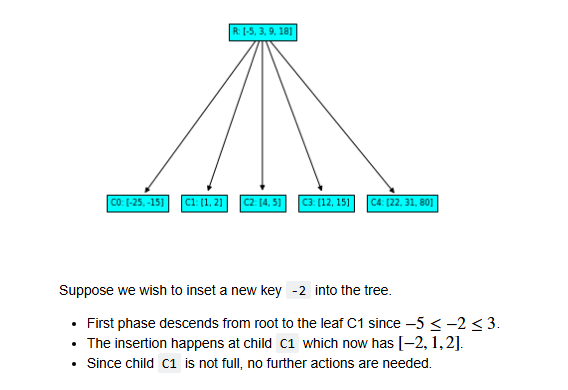

In [30]:
b = b.insert(-2)
b.rep_ok()
draw_btree_graph(b)

AssertionError: 

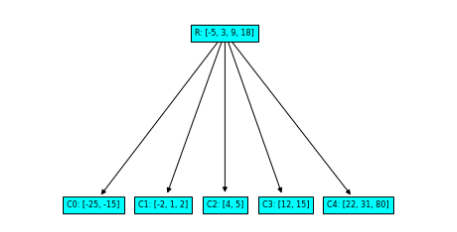
Suppose we would like to insert  71
 , what would happen?

In [31]:
b = b.insert(71)
b.rep_ok()
draw_btree_graph(b)

AssertionError: 

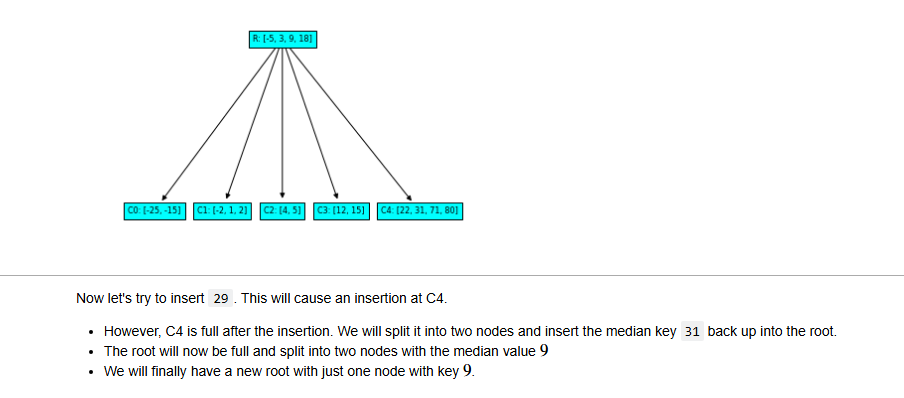

In [32]:
b = b.insert(29)
b.rep_ok()
draw_btree_graph(b)

AssertionError: 

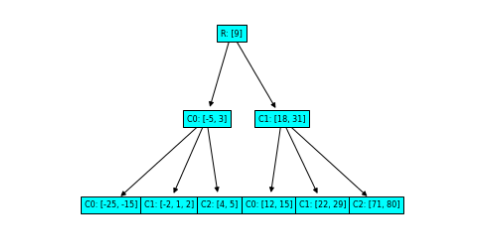

In [33]:
b.insert(16)
draw_btree_graph(b)

AssertionError: 

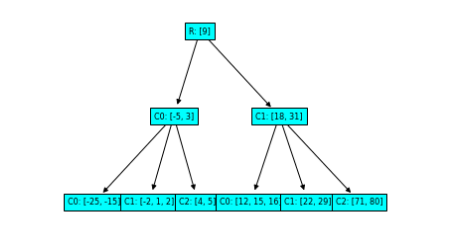
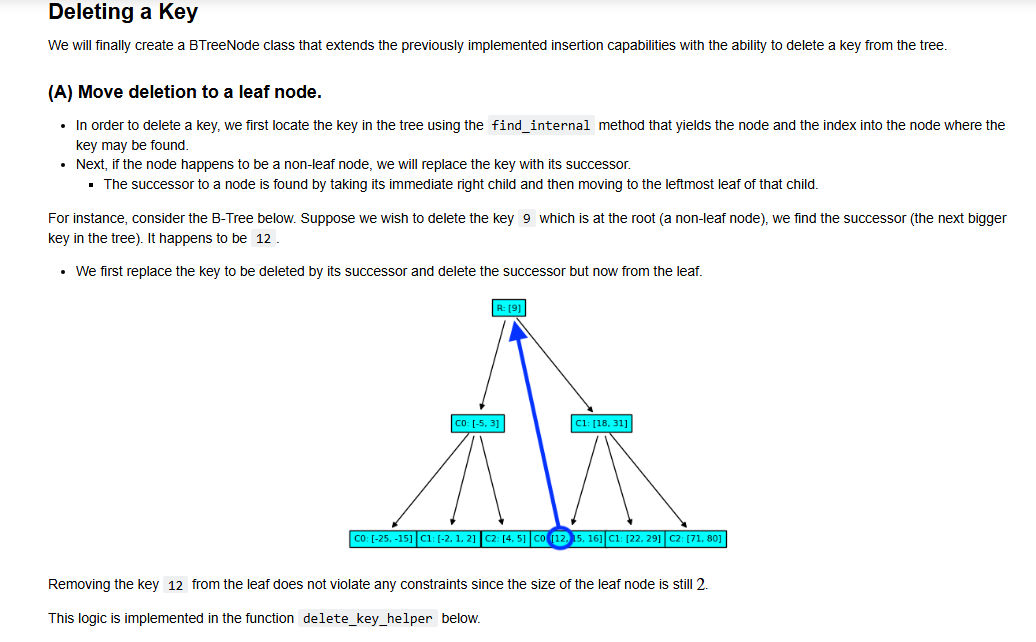
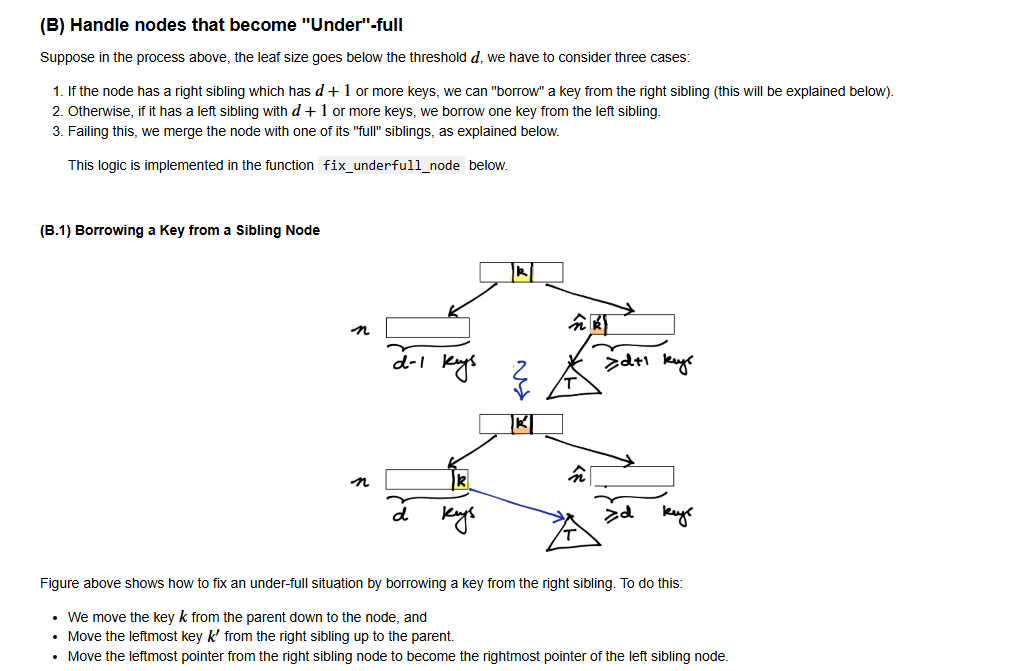
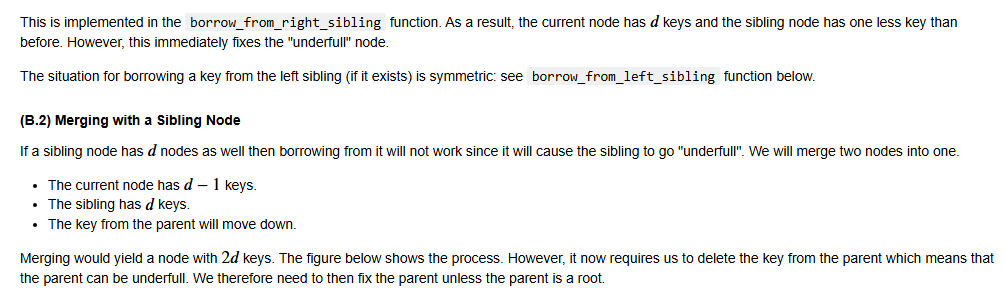
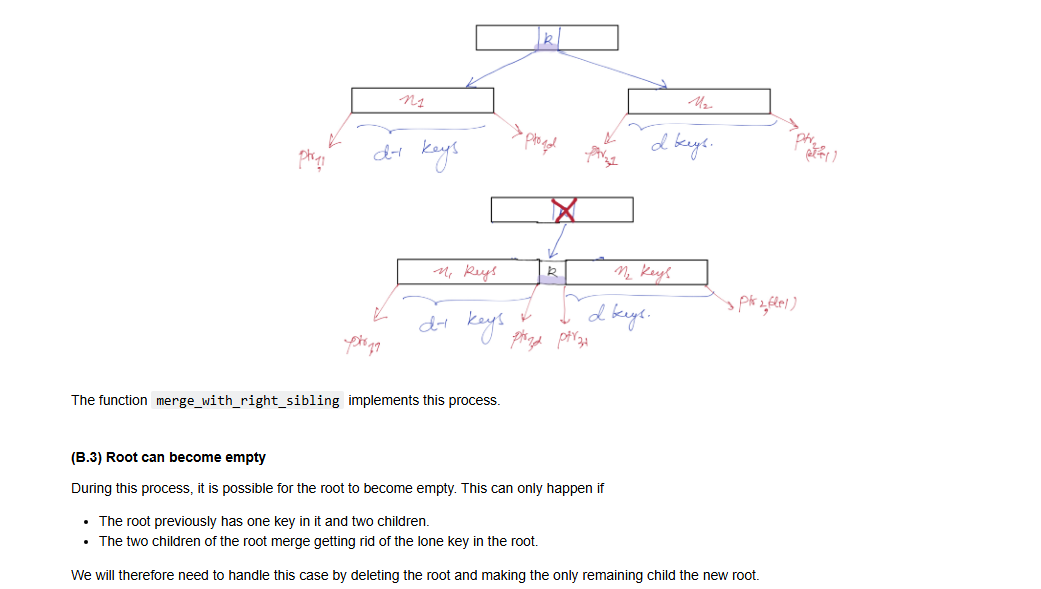

In [34]:
class BTreeNode(BTreeNodeWithInsert):
    
    def __init__(self, keys = [], ptrs = [], is_root=False, d = 10):
        super().__init__(keys, ptrs, is_root, d)
    
    def create_new_instance(self, keys, ptrs, is_root, d):
        """We need this to construct a new instance because we chose to split the implementation across three different classes"""
        return BTreeNode(keys, ptrs, is_root, d)
    
    def delete_key(self, key_to_delete):
        """This is the main routine to delete a key from the tree. It should be called at the root of the tree."""
        assert self.is_root # call this routine only at the root.
        result = self.delete_key_helper(key_to_delete) # call the helper method 
        if result == None:
            # root did not change 
            return self
        else:
            return result # result is the new root node for the tree 
        
    def delete_key_helper(self, key_to_delete, debug=True):
        """This is the main worker method for deleting a key from the tree."""
        # first find the node in the tree that has the key 
        res = self.find_key_internal(key_to_delete)
        if res == None: # the node was not found, nothing to delete
            print(f'Key {key_to_delete} does not exist in the tree') # warn the user 
            return None # bail!
        #Otherwise, we have found the key and now need to delete it.
        (node, idx) = res # unpack the result of find_key_internal to obtain the node and its index
        assert 0 <= idx and idx < len(node.keys) # idx is a proper index into the list of keys
        assert node.keys[idx] == key_to_delete # if this fails then our find routine is messed up!
        if not node.is_leaf(): # if it is not a leaf node
            (succ_key, successor_leaf_node) = node.find_successor(idx) # find successor key and node
            assert successor_leaf_node.is_leaf() 
            assert succ_key > node.keys[idx], f"Successor: {succ_key}, node key {node.keys[idx]}"
            assert succ_key == successor_leaf_node.keys[0]
            # replace the key with that of the successor
            if debug:
                print(f'Replacing {key_to_delete} with sucessor key {succ_key}')
            node.keys[idx] = succ_key # replace key with successor
            return successor_leaf_node.delete_key_leaf(0, debug) # delete the sucessor key starting from the leaf
        else: # deletion  is already at a leaf node
            return node.delete_key_leaf(idx, debug) # delete the key starting from the leaf
            
    def delete_key_leaf(self, idx, debug=True):
        """Delete a key that is at the leaf. self is a leaf node and idx is the index into the list of keys that needs to be deleted"""
        assert self.is_leaf() # do not call this method on a non-leaf method
        n = len(self.keys) 
        d = self.d
        assert 0 <= idx and idx < n
        for i in range(idx, n-1):
            self.keys[i] = self.keys[i+1] # move keys to the left, overwriting the key at position idx
        self.keys.pop() # remove the very last element 
        assert len(self.keys) == n-1 # I have deceased by one key
        if self.is_root or (n-1) >= d:  # check if I am underfull
            return None # not underfull -- nothing more to do
        else:
            # we have an underfull situation
            print(f'Delete causes node with keys {self.keys} to be under-full')
            return self.fix_underfull_node(debug) # fix the underfull node (see below)
    
    def fix_underfull_node(self, debug=True):
        """ Fix a node that has gone under-full as a result of deleting a key. """
        if self.is_root: # if we are aleady at the root, nothing to fix
            return None # nothing to fix
        if len(self.keys) >= self.d: # the node better be underfull
            return None # if not, bail out
        # node is actually underfull
        assert len(self.keys) == self.d -1  
        n = len(self.keys) 
        d = self.d
        assert self.parent != None # it is not the root, so it must have a parent node
        (parent_node, node_idx) = self.parent # fetch the parent node and the idx 
        n_parent = len(parent_node.keys) # how many keys does the parent have
        assert n_parent >= 1 # parent must always have one or more keys or else we have caused a property violation
        if node_idx <= n_parent-1 : 
            # I have a sibling to the right
            right_sibling_node = parent_node.pointers[node_idx+1]
            # Does the right sibling node have space
            n_right_sibling = len(right_sibling_node.keys)
            if n_right_sibling > d: 
                if debug:
                    print('Borrowing key from right sibling')
                self.borrow_from_right_sibling(right_sibling_node)
            else:
                if debug:
                    print('Merging with right sibling')
                # merge with right sibling -- note this will delete a key from the parent.
                self.merge_with_right_sibling(right_sibling_node)
                if parent_node.is_root and len(parent_node.keys) == 0:
                    # Merge caused an empty root 
                    if debug:
                        print('Root became empty: designating new root.')
                    self.parent = None
                    self.is_root = True
                    self.fix_parent_pointers_for_children()
                    return self
        else:
            assert node_idx >= 1
            # I have a sibling to the left
            left_sibling_node = parent_node.pointers[node_idx-1]
            # Does the left sibling node have space
            n_left_sibling = len(left_sibling_node.keys)
            if n_left_sibling > d: 
                if debug:
                    print('Borrowing from left sibling')
                self.borrow_from_left_sibling(left_sibling_node)
            else:
                if debug:
                    print('Merging with left sibling')
                # merge the left sibling with myself (since I am the right sibling of my left sibling)
                # note this will cause a key to be removed from the parent
                left_sibling_node.merge_with_right_sibling(self)
                if parent_node.is_root and len(parent_node.keys) == 0:
                    # Merge caused an empty root 
                    if debug:
                        print('Root became empty: designating new root.')
                    left_sibling_node.parent = None
                    left_sibling_node.is_root = True
                    left_sibling_node.fix_parent_pointers_for_children()
                    return left_sibling_node
                
        # if the parent is not a root and it has become underfull
        if not parent_node.is_root and len(parent_node.keys) < d: 
            # parent node is underfull, recursively fix the parent
            return parent_node.fix_underfull_node()
    
    def borrow_from_right_sibling(self, right_sibling_node):
        """Borrow a key from the right sibling node. Note that it should not become underfull as a result of the borrow"""
        assert self.parent != None
        (parent_node, parent_idx) = self.parent # get the parent
        assert right_sibling_node.parent != None
        assert right_sibling_node.parent[0] == parent_node, f"right sibling parent {right_sibling_node.parent[0]} my parent {parent_node}"
        assert right_sibling_node.parent[1] == parent_idx+1 # make sure that right_sibling node is indeed the right sibling node
        n_right_sibling = len(right_sibling_node.keys)
        assert n_right_sibling >= self.d + 1
        # Borrow key from right sibling
        # move key from parent down to self
        self.keys.append(parent_node.keys[parent_idx]) # add the parent key to myself
        parent_node.keys[parent_idx] = right_sibling_node.keys[0] # replace the parent key with leftmost key of right sibling
        right_sibling_node.keys.pop(0) # remove leftmost key from right sibling
        if not self.is_leaf(): # if it is not a leaf node, we have to fix the pointers as well
            assert not right_sibling_node.is_leaf() 
            # move pointer from right sibling down to self
            new_child_node = right_sibling_node.pointers[0] #get the leftmost pointer from right sibling
            self.pointers.append(new_child_node) # make it my rightmost pointer
            right_sibling_node.pointers.pop(0) # delete leftmost pointer from right sibling
            self.fix_parent_pointers_for_children() # fix the parent pointers to children from myself and right sibling
            right_sibling_node.fix_parent_pointers_for_children()
        return 
    
    def borrow_from_left_sibling(self, left_sibling_node):
        """Borrow a key from left sibling node. Similar structure as borrow_from_right_sibling function above."""
        assert self.parent != None
        (parent_node, parent_idx) = self.parent
        assert left_sibling_node.parent != None
        assert left_sibling_node.parent[0] == parent_node
        assert left_sibling_node.parent[1] == parent_idx-1
        n_sibling = len(left_sibling_node.keys)
        assert n_sibling >= self.d + 1
        self.keys.insert(0, parent_node.keys[parent_idx-1]) # insert the parent key as my leftmost key
        parent_node.keys[parent_idx-1] = left_sibling_node.keys[n_sibling-1] # replace the parent key with rightmost key of the left sibling
        left_sibling_node.keys.pop() # remove the rightmost key of left sibling
        if not self.is_leaf(): # if not a leaf, then pointers must be fixed
            assert not left_sibling_node.is_leaf() 
            self.pointers.insert(0, left_sibling_node.pointers[n_sibling]) # insert the rightmost pointer of left sibling as my leftmost pointer
            left_sibling_node.pointers.pop() # delete the rightmost pointer from left sibling
            self.fix_parent_pointers_for_children() # fix the parent pointers for my children and those of the left sibling
            left_sibling_node.fix_parent_pointers_for_children()
        return 
    

    
    def merge_with_right_sibling(self, right_sibling_node):
        """Merge with the right sibling to form a single node. Results in deletion of a key from the parent node."""
         # Merge with left sibling node to form a single node
        assert self.parent != None
        (parent_node, parent_idx) = self.parent
        assert right_sibling_node.parent != None
        assert right_sibling_node.parent[0] == parent_node
        assert right_sibling_node.parent[1] == parent_idx+1
        self.keys = self.keys + [parent_node.keys[parent_idx]] + right_sibling_node.keys # append the keys together, also get the parent node key as well
        assert len(self.keys) == 2 * self.d
        if not self.is_leaf(): # now fix the pointers
            assert not right_sibling_node.is_leaf()
            self.pointers = self.pointers + right_sibling_node.pointers # append the pointers
            assert len(self.pointers) == 2 * self.d + 1, f'Number of pointers = {len(self.pointers)}, d = {self.d}'
        parent_node.keys.pop(parent_idx) # remove the key from the parent
        parent_node.pointers.pop(parent_idx + 1) # remove the pointer from the parent to the right sibling node
        parent_node.fix_parent_pointers_for_children() # fix children pointers for the parent
        if not self.is_leaf():
            self.fix_parent_pointers_for_children() # fix my own children pointers
        return 
    
            
    
            
    
        

In [35]:
#Consider the example
lst = [1, 5, 2, 4, 3, 9, 15, -5, 12, 18, 80, -25, 22, 31, -15, -2, 71, 29, 16]
b = BTreeNode(d=2,is_root=True)
for k in lst:
    b = b.insert(k)
b.rep_ok()
draw_btree_graph(b)

AttributeError: 'BTreeNode' object has no attribute 'make_networkx_graph'

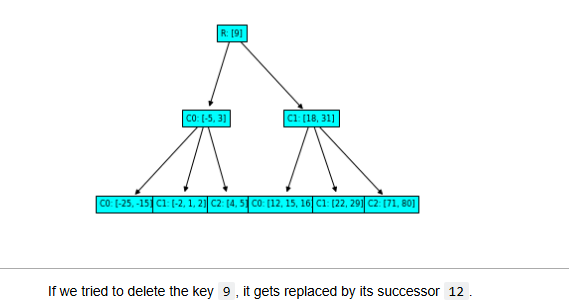

In [36]:
b = b.delete_key(9)
b.rep_ok()
draw_btree_graph(b)

AttributeError: 'BTreeNode' object has no attribute 'find_key_internal'

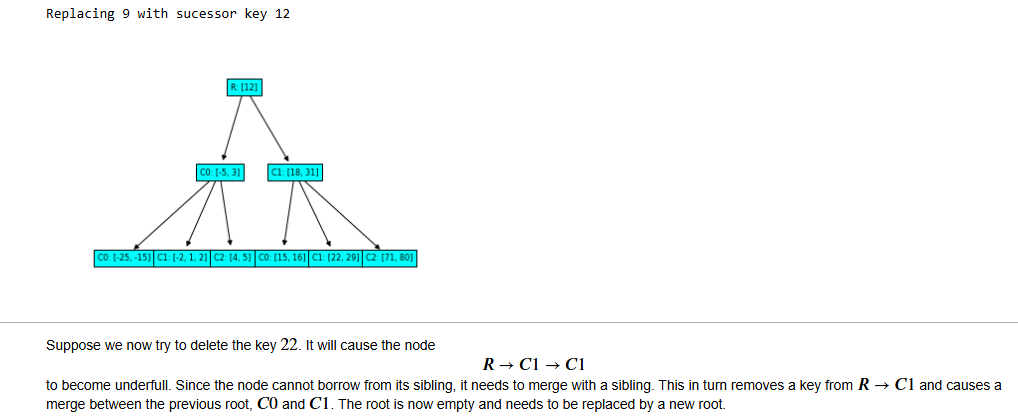

In [37]:
b = b.delete_key(22)
b.rep_ok()
draw_btree_graph(b)

AttributeError: 'BTreeNode' object has no attribute 'find_key_internal'

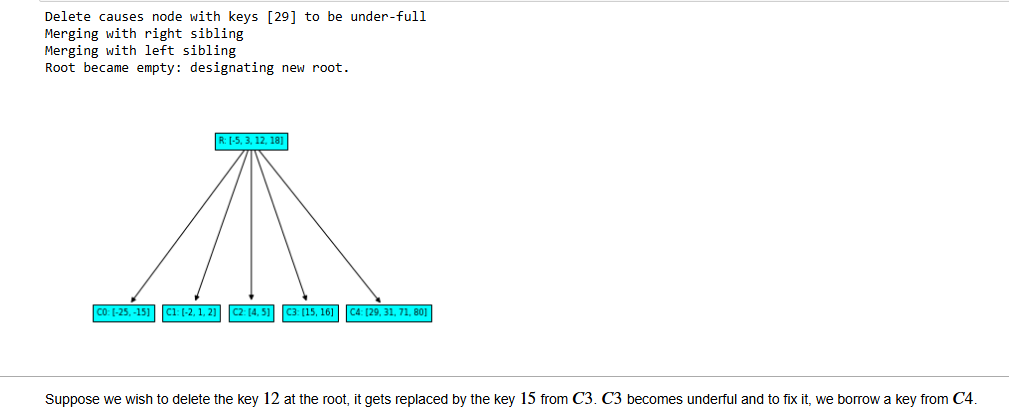

In [38]:
b = b.delete_key(12)
b.rep_ok()
draw_btree_graph(b)

AttributeError: 'BTreeNode' object has no attribute 'find_key_internal'

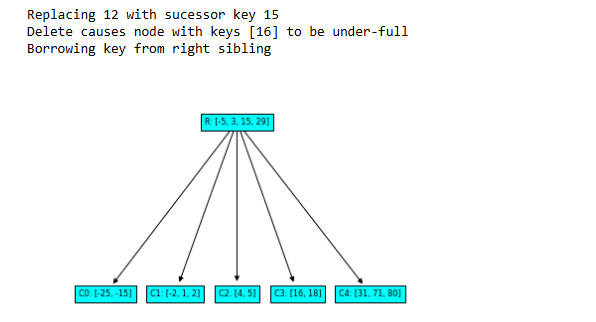

In [39]:
from random import shuffle
l = list(range(-40,40))
shuffle(l)
print(l)
b = BTreeNode(d=3,is_root=True)
for j in l:
    b = b.insert(j)
b.rep_ok()
draw_btree_graph(b)

[31, -32, -26, 27, 34, 32, 3, 37, 16, -25, 17, 14, 7, 38, -28, -3, -16, -14, -17, 22, 18, 8, 29, 36, 0, 9, -40, -21, -19, 10, -12, 28, -33, -38, 24, 19, -5, -39, -1, -18, -11, -4, 30, 26, -24, 12, 6, -10, 33, -37, 11, -20, 39, 21, -8, -13, -31, 20, 2, -7, 23, -35, 1, -23, -2, 25, -9, -29, 15, -27, -15, 13, 5, -30, 35, -22, -34, -36, -6, 4]
Key 16 already exists


AssertionError: key 2 already exists [-1, 0, 1, 2]

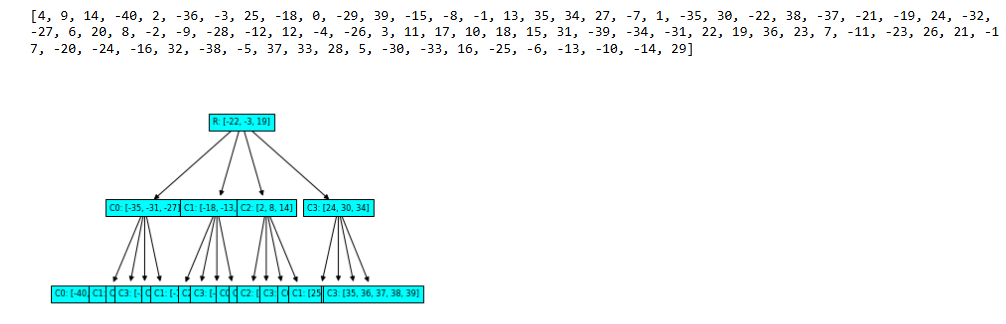

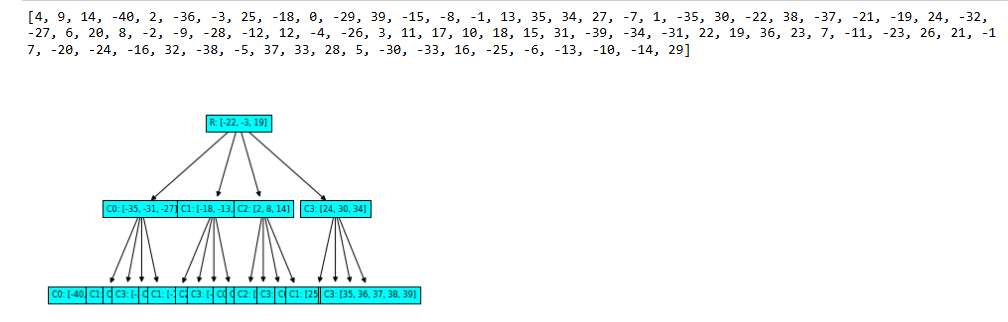

In [40]:
from random import shuffle
l = list(range(-500,500))
shuffle(l)
print(l)
b = BTreeNode(d=7,is_root=True)
for j in l:
    b = b.insert(j)
b.rep_ok()
display(draw_btree_graph(b))
for i in range(-425, 420):
    if b.find_key(i):
        b = b.delete_key(i)
b.rep_ok()
draw_btree_graph(b)

[-373, -133, 12, -388, 496, -115, 365, -64, -473, -112, 252, -335, 165, 377, 220, 176, -38, 137, -316, -294, -75, 243, 214, -290, -34, 119, 53, -224, 387, 52, -136, 338, 290, -217, -113, 451, -492, -480, -27, -73, 367, 135, 457, -13, -124, 47, 321, 106, -477, 236, 203, 149, -491, -415, -24, 308, -225, -139, -198, 412, 424, 16, 217, 480, -304, -474, 241, 256, 89, -47, -452, 117, -432, -247, -484, -447, 411, -375, 378, 497, 132, 300, 234, 473, -43, 50, -298, 347, -214, 3, -160, -424, -245, 168, -80, 179, 319, -313, 277, 482, 349, 355, -385, 262, -60, 249, -230, 42, -322, 245, -11, -22, 92, 173, -287, -156, -306, -486, 113, -138, 471, 221, 436, 104, -177, -39, 278, 425, -341, 390, -129, -118, -376, 294, 100, 307, 253, -330, -500, 323, -100, -292, -441, 266, 199, 268, 65, 427, 490, -362, -356, -268, 435, 374, -476, 166, -323, 293, -6, -152, 285, 240, 385, -327, 420, 159, 108, -488, 171, 202, -170, -444, 71, -162, -219, -77, 2, -174, -411, 260, -422, 21, 225, 433, 357, -345, -485, -281, -41

AssertionError: key 3 already exists [3, 4, 5, 12, 16, 31, 47, 50]

[-44, 438, -110, -121, -175, 367, -221, -132, -64, 164, 27, -268, -348, -283, -309, -474, -401, 372, 292, 117, 198, 61, 320, 417, -463, -141, 345, 365, 30, -443, 109, -406, -472, 489, 347, 229, 373, 29, 407, 487, -244, 354, -438, -277, -196, 92, 74, -379, -123, -476, 454, 281, -385, -13, -371, 78, 126, -111, 205, 167, -479, 85, 424, 301, 216, 0, -392, 389, -11, -466, 133, 239, -316, -100, 453, -66, -51, 11, -225, -195, -78, -255, 391, 419, -2, 400, 144, 430, 304, -449, 382, 299, -402, 316, 253, -143, -439, -264, -367, -297, 24, -342, 437, 250, -386, -310, -452, 474, 363, -220, -232, -442, 330, 93, 425, -284, 317, -423, -170, 245, 12, 369, -308, 48, -19, -391, 343, -288, -372, -107, 28, -17, -199, 443, 296, 161, -224, -236, -300, 375, 37, 72, 331, 179, 381, -242, -125, -279, 149, 364, -329, -344, 255, -213, -88, 294, -49, -274, 65, -262, -174, 395, 119, -469, 160, 409, -488, 228, -235, 211, 251, -186, 183, -130, 440, 349, 204, 156, -200, -77, 163, 180, -307, -59, -447, 348, -134, 450, 111, 366, -334, -360, -389, 170, 488, 91, 308, -8, 208, 472, 43, -465, -38, 66, -393, -303, 15, -89, -58, 499, 303, 16, -150, 41, -79, 278, 293, 159, 464, -301, -237, 380, 458, 309, 173, 394, -31, 112, 51, 338, -486, 113, -248, -156, -397, -149, 178, 439, 359, 340, -271, 97, -493, 226, -21, 79, 310, 89, -176, -338, -364, 436, 327, 496, 314, -54, 259, -278, 272, -154, -46, -152, -324, -207, 192, 218, 39, -91, -158, -326, 153, -313, -365, -345, 137, 478, -433, 248, 196, -90, -416, -366, -252, -122, 17, -194, 22, 9, 232, 392, 207, -450, -375, -419, 102, 270, 385, 214, 383, -405, 351, -168, -214, 298, 337, 136, 165, -373, -144, -382, -211, 285, 3, -139, 498, -86, 452, 280, -312, -30, -129, -280, -261, -343, 325, -16, -203, -24, 388, 181, 210, 21, 336, 158, 324, 25, 416, -351, 82, 312, 356, 36, 379, -94, -451, 334, -333, -349, 135, 341, -87, -418, -50, 215, 322, -292, -485, 75, 468, 52, -457, 480, -471, 125, -112, 90, -34, 306, -399, 378, 231, -190, -222, 469, -356, -240, -388, -1, -270, 269, 268, 332, 254, -127, 131, -26, 139, 413, 420, 47, 448, 185, -189, 184, 26, -431, 256, -204, -95, -10, -229, -98, -263, -40, -208, 222, -177, 230, -106, -109, 479, -256, -400, -336, -368, -467, -65, 20, -448, -318, 286, -432, 350, -29, 209, 237, 120, -183, -328, 55, 352, 412, -193, -272, 249, 44, -355, 283, 318, 148, -253, -136, -322, 81, 427, -299, 54, -491, 189, 465, 357, 266, -275, -258, -97, -68, 219, -412, -215, -178, -295, 244, 238, 107, -358, 342, 277, -354, -302, -499, -243, 433, 235, -394, -115, 353, 435, 390, 200, -411, 224, -306, -140, 261, 105, -396, 116, -337, 275, 319, -422, 346, -114, 94, -246, 103, 199, -403, -359, -426, -340, -23, 485, 429, -254, -380, -468, -315, -32, 442, 213, 154, -424, 233, -304, 138, -43, 476, -298, 242, -427, -266, 361, -421, -408, 377, 295, 329, -185, -96, 201, 18, 398, 197, 168, -383, -202, -473, -331, 426, 38, -191, 290, 466, -227, -293, -84, 124, 193, 240, -497, 71, -7, -294, 477, -128, 408, 387, -163, -104, 114, 284, 265, -159, 129, 194, -108, 386, -92, 246, -286, 470, -291, 492, -101, 141, -205, 321, -404, -417, 288, 49, -265, -332, 234, -218, -305, -257, 279, -441, -494, 307, 175, 77, -99, -172, 4, 335, 457, -247, -212, 404, -209, 401, 146, -116, -317, -462, 202, 393, -80, -341, 70, -217, 63, 98, 445, -238, -184, 87, 260, -81, 134, -55, -192, -157, 150, -475, -420, -28, -198, -131, 142, -219, -398, 225, 110, -249, -436, 432, 45, -323, -429, -269, -166, 328, 362, -39, -500, 42, 83, -27, 186, -71, 494, 374, 191, -347, -181, 62, 76, -233, 282, 297, -378, -124, 267, 13, -377, -223, 80, 305, 415, -9, 434, 484, -206, -260, -245, -259, 402, -425, -41, -320, 64, -148, -187, 155, 428, -369, -434, 471, 371, 481, -197, 497, 10, -165, -282, 84, 467, -489, -330, -267, 410, 96, -6, -138, -374, 143, 32, -387, 493, -171, 172, -350, 403, -126, -147, -484, -413, -73, -440, 462, -319, 323, -455, 355, -180, -428, -72, -490, -410, -481, -60, 123, -281, -487, -409, 339, -444, 300, 483, 68, -314, -14, -395, -437, 274, -53, 190, 151, -498, 368, 6, -414, 171, 34, 257, 418, -33, 384, -327, 326, -113, -35, 315, 456, -37, -45, 344, 132, -169, 441, 99, -117, 58, 289, 121, 236, -482, -445, 174, -381, -133, 396, -4, 360, 31, -161, -164, 461, -357, 86, 33, 40, 206, 104, 451, 19, -25, -57, -5, 397, -362, 67, 399, 252, 7, 444, -289, -48, 414, 57, 495, 5, -296, -446, -15, -492, -146, 118, 370, -241, -119, 100, 203, 14, 276, -458, -102, -384, -495, -231, -42, 311, 223, 128, 431, 405, -285, -75, 88, 162, 69, -160, 60, 460, -70, 187, 486, -228, -325, 8, -167, 101, 145, -352, -56, -250, -74, -142, -18, -151, -61, 491, -201, -464, -239, -454, 313, 182, -155, -135, 422, -353, -36, -188, 258, 166, -173, 264, -453, 177, -456, 212, 247, 490, -461, 217, 176, 287, 220, -460, -179, 423, 152, 447, 108, -103, 227, 411, -12, 122, -82, -83, -376, -276, -62, 358, 50, -478, 459, -162, -226, -363, -477, 455, 2, 56, -480, -137, 195, 169, -216, 271, 59, 243, 188, 291, -430, 333, 130, -483, -153, 463, 140, -118, 473, -67, 1, -346, 406, -3, -52, 73, -370, -47, -335, 421, -230, -273, 273, -407, -390, -251, 262, 127, -435, -145, 376, 53, -311, 302, 106, -120, -85, -415, -290, -93, -20, -361, 263, 115, -234, 449, 482, 446, -76, -287, 241, 157, 46, -339, -105, -63, 147, -496, 221, -22, -470, -459, 23, 35, 95, -182, -69, -210, -321, 475]
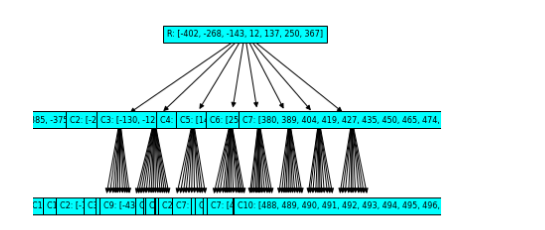

None
Delete causes node with keys [-426, -424, -423, -422, -421, -420] to be under-full
Borrowing key from right sibling
Delete causes node with keys [-426, -423, -422, -421, -420, -419] to be under-full
Merging with right sibling
Delete causes node with keys [-426, -415, -414, -413, -412, -411] to be under-full
Merging with right sibling
Delete causes node with keys [-426, -407, -406, -405, -404, -403] to be under-full
Borrowing from left sibling
Delete causes node with keys [-427, -426, -406, -405, -404, -403] to be under-full
Borrowing from left sibling
Delete causes node with keys [-428, -427, -426, -405, -404, -403] to be under-full
Borrowing from left sibling
Delete causes node with keys [-429, -428, -427, -426, -404, -403] to be under-full
Merging with left sibling
Borrowing key from right sibling
Replacing -402 with sucessor key -401
Delete causes node with keys [-400, -399, -398, -397, -396, -395] to be under-full
Borrowing from left sibling
Delete causes node with keys [-400, -399, -398, -397, -396, -395] to be under-full
Borrowing from left sibling
Delete causes node with keys [-426, -399, -398, -397, -396, -395] to be under-full
Borrowing from left sibling
Delete causes node with keys [-427, -426, -398, -397, -396, -395] to be under-full
Borrowing from left sibling
Delete causes node with keys [-428, -427, -426, -397, -396, -395] to be under-full
Borrowing from left sibling
Delete causes node with keys [-429, -428, -427, -426, -396, -395] to be under-full
Merging with left sibling
Borrowing key from right sibling
Replacing -394 with sucessor key -393
Replacing -393 with sucessor key -392
Delete causes node with keys [-391, -390, -389, -388, -387, -386] to be under-full
Borrowing from left sibling
Delete causes node with keys [-391, -390, -389, -388, -387, -386] to be under-full
Borrowing from left sibling
Delete causes node with keys [-426, -390, -389, -388, -387, -386] to be under-full
Borrowing from left sibling
Delete causes node with keys [-427, -426, -389, -388, -387, -386] to be under-full
Borrowing from left sibling
Delete causes node with keys [-428, -427, -426, -388, -387, -386] to be under-full
Borrowing from left sibling
Delete causes node with keys [-429, -428, -427, -426, -387, -386] to be under-full
Merging with left sibling
Borrowing key from right sibling
Replacing -385 with sucessor key -384
Replacing -384 with sucessor key -383
Replacing -383 with sucessor key -382
Delete causes node with keys [-381, -380, -379, -378, -377, -376] to be under-full
Borrowing from left sibling
Delete causes node with keys [-381, -380, -379, -378, -377, -376] to be under-full
Borrowing from left sibling
Delete causes node with keys [-426, -380, -379, -378, -377, -376] to be under-full
Borrowing from left sibling
Delete causes node with keys [-427, -426, -379, -378, -377, -376] to be under-full
Borrowing from left sibling
Delete causes node with keys [-428, -427, -426, -378, -377, -376] to be under-full
Borrowing from left sibling
Delete causes node with keys [-429, -428, -427, -426, -377, -376] to be under-full
Merging with left sibling
Borrowing key from right sibling
Replacing -375 with sucessor key -374
Replacing -374 with sucessor key -373
Delete causes node with keys [-372, -371, -370, -369, -368, -367] to be under-full
Borrowing from left sibling
Delete causes node with keys [-372, -371, -370, -369, -368, -367] to be under-full
Borrowing from left sibling
Delete causes node with keys [-426, -371, -370, -369, -368, -367] to be under-full
Borrowing from left sibling
Delete causes node with keys [-427, -426, -370, -369, -368, -367] to be under-full
Borrowing from left sibling
Delete causes node with keys [-428, -427, -426, -369, -368, -367] to be under-full
Borrowing from left sibling
Delete causes node with keys [-429, -428, -427, -426, -368, -367] to be under-full
Merging with left sibling
Borrowing key from right sibling
Replacing -366 with sucessor key -365
Replacing -365 with sucessor key -364
Replacing -364 with sucessor key -363
Replacing -363 with sucessor key -362
Delete causes node with keys [-361, -360, -359, -358, -357, -356] to be under-full
Borrowing from left sibling
Delete causes node with keys [-361, -360, -359, -358, -357, -356] to be under-full
Borrowing from left sibling
Delete causes node with keys [-426, -360, -359, -358, -357, -356] to be under-full
Borrowing from left sibling
Delete causes node with keys [-427, -426, -359, -358, -357, -356] to be under-full
Borrowing from left sibling
Delete causes node with keys [-428, -427, -426, -358, -357, -356] to be under-full
Borrowing from left sibling
Delete causes node with keys [-429, -428, -427, -426, -357, -356] to be under-full
Merging with left sibling
Borrowing key from right sibling
Replacing -355 with sucessor key -354
Replacing -354 with sucessor key -353
Replacing -353 with sucessor key -352
Replacing -352 with sucessor key -351
Delete causes node with keys [-350, -349, -348, -347, -346, -345] to be under-full
Borrowing from left sibling
Delete causes node with keys [-350, -349, -348, -347, -346, -345] to be under-full
Borrowing from left sibling
Delete causes node with keys [-426, -349, -348, -347, -346, -345] to be under-full
Borrowing from left sibling
Delete causes node with keys [-427, -426, -348, -347, -346, -345] to be under-full
Borrowing from left sibling
Delete causes node with keys [-428, -427, -426, -347, -346, -345] to be under-full
Borrowing from left sibling
Delete causes node with keys [-429, -428, -427, -426, -346, -345] to be under-full
Merging with left sibling
Borrowing key from right sibling
Replacing -344 with sucessor key -343
Delete causes node with keys [-342, -341, -340, -339, -338, -337] to be under-full
Borrowing from left sibling
Delete causes node with keys [-342, -341, -340, -339, -338, -337] to be under-full
Borrowing from left sibling
Delete causes node with keys [-426, -341, -340, -339, -338, -337] to be under-full
Borrowing from left sibling
Delete causes node with keys [-427, -426, -340, -339, -338, -337] to be under-full
Borrowing from left sibling
Delete causes node with keys [-428, -427, -426, -339, -338, -337] to be under-full
Borrowing from left sibling
Delete causes node with keys [-429, -428, -427, -426, -338, -337] to be under-full
Merging with left sibling
Merging with right sibling
Replacing -336 with sucessor key -335
Delete causes node with keys [-334, -333, -332, -331, -330, -329] to be under-full
Borrowing key from right sibling
Replacing -335 with sucessor key -334
Delete causes node with keys [-333, -332, -331, -330, -329, -328] to be under-full
Borrowing key from right sibling
Replacing -334 with sucessor key -333
Delete causes node with keys [-332, -331, -330, -329, -328, -327] to be under-full
Merging with right sibling
Replacing -333 with sucessor key -332
Replacing -332 with sucessor key -331
Replacing -331 with sucessor key -330
Replacing -330 with sucessor key -329
Replacing -329 with sucessor key -328
Replacing -328 with sucessor key -327
Replacing -327 with sucessor key -326
Replacing -326 with sucessor key -325
Delete causes node with keys [-324, -323, -322, -321, -320, -319] to be under-full
Borrowing key from right sibling
Replacing -325 with sucessor key -324
Delete causes node with keys [-323, -322, -321, -320, -319, -318] to be under-full
Merging with right sibling
Replacing -324 with sucessor key -323
Replacing -323 with sucessor key -322
Replacing -322 with sucessor key -321
Replacing -321 with sucessor key -320
Replacing -320 with sucessor key -319
Replacing -319 with sucessor key -318
Replacing -318 with sucessor key -317
Replacing -317 with sucessor key -316
Delete causes node with keys [-315, -314, -313, -312, -311, -310] to be under-full
Borrowing key from right sibling
Replacing -316 with sucessor key -315
Delete causes node with keys [-314, -313, -312, -311, -310, -309] to be under-full
Merging with right sibling
Replacing -315 with sucessor key -314
Replacing -314 with sucessor key -313
Replacing -313 with sucessor key -312
Replacing -312 with sucessor key -311
Replacing -311 with sucessor key -310
Replacing -310 with sucessor key -309
Replacing -309 with sucessor key -308
Replacing -308 with sucessor key -307
Delete causes node with keys [-306, -305, -304, -303, -302, -301] to be under-full
Merging with right sibling
Replacing -307 with sucessor key -306
Replacing -306 with sucessor key -305
Replacing -305 with sucessor key -304
Replacing -304 with sucessor key -303
Replacing -303 with sucessor key -302
Replacing -302 with sucessor key -301
Replacing -301 with sucessor key -300
Replacing -300 with sucessor key -299
Delete causes node with keys [-298, -297, -296, -295, -294, -293] to be under-full
Merging with right sibling
Replacing -299 with sucessor key -298
Replacing -298 with sucessor key -297
Replacing -297 with sucessor key -296
Replacing -296 with sucessor key -295
Replacing -295 with sucessor key -294
Replacing -294 with sucessor key -293
Replacing -293 with sucessor key -292
Replacing -292 with sucessor key -291
Delete causes node with keys [-290, -289, -288, -287, -286, -285] to be under-full
Merging with right sibling
Replacing -291 with sucessor key -290
Replacing -290 with sucessor key -289
Replacing -289 with sucessor key -288
Replacing -288 with sucessor key -287
Replacing -287 with sucessor key -286
Replacing -286 with sucessor key -285
Replacing -285 with sucessor key -284
Replacing -284 with sucessor key -283
Delete causes node with keys [-282, -281, -280, -279, -278, -277] to be under-full
Merging with right sibling
Replacing -283 with sucessor key -282
Replacing -282 with sucessor key -281
Replacing -281 with sucessor key -280
Replacing -280 with sucessor key -279
Replacing -279 with sucessor key -278
Replacing -278 with sucessor key -277
Replacing -277 with sucessor key -276
Replacing -276 with sucessor key -275
Delete causes node with keys [-274, -273, -272, -271, -270, -269] to be under-full
Borrowing from left sibling
Delete causes node with keys [-274, -273, -272, -271, -270, -269] to be under-full
Borrowing from left sibling
Delete causes node with keys [-426, -273, -272, -271, -270, -269] to be under-full
Borrowing from left sibling
Delete causes node with keys [-427, -426, -272, -271, -270, -269] to be under-full
Borrowing from left sibling
Delete causes node with keys [-428, -427, -426, -271, -270, -269] to be under-full
Borrowing from left sibling
Delete causes node with keys [-429, -428, -427, -426, -270, -269] to be under-full
Merging with left sibling
Borrowing key from right sibling
Replacing -268 with sucessor key -267
Replacing -267 with sucessor key -266
Replacing -266 with sucessor key -265
Replacing -265 with sucessor key -264
Replacing -264 with sucessor key -263
Replacing -263 with sucessor key -262
Delete causes node with keys [-261, -260, -259, -258, -257, -256] to be under-full
Borrowing from left sibling
Delete causes node with keys [-261, -260, -259, -258, -257, -256] to be under-full
Borrowing from left sibling
Delete causes node with keys [-426, -260, -259, -258, -257, -256] to be under-full
Borrowing from left sibling
Delete causes node with keys [-427, -426, -259, -258, -257, -256] to be under-full
Borrowing from left sibling
Delete causes node with keys [-428, -427, -426, -258, -257, -256] to be under-full
Borrowing from left sibling
Delete causes node with keys [-429, -428, -427, -426, -257, -256] to be under-full
Merging with left sibling
Borrowing key from right sibling
Replacing -255 with sucessor key -254
Replacing -254 with sucessor key -253
Replacing -253 with sucessor key -252
Replacing -252 with sucessor key -251
Replacing -251 with sucessor key -250
Replacing -250 with sucessor key -249
Delete causes node with keys [-248, -247, -246, -245, -244, -243] to be under-full
Borrowing from left sibling
Delete causes node with keys [-248, -247, -246, -245, -244, -243] to be under-full
Borrowing from left sibling
Delete causes node with keys [-426, -247, -246, -245, -244, -243] to be under-full
Borrowing from left sibling
Delete causes node with keys [-427, -426, -246, -245, -244, -243] to be under-full
Borrowing from left sibling
Delete causes node with keys [-428, -427, -426, -245, -244, -243] to be under-full
Borrowing from left sibling
Delete causes node with keys [-429, -428, -427, -426, -244, -243] to be under-full
Merging with left sibling
Borrowing key from right sibling
Replacing -242 with sucessor key -241
Replacing -241 with sucessor key -240
Replacing -240 with sucessor key -239
Delete causes node with keys [-238, -237, -236, -235, -234, -233] to be under-full
Borrowing from left sibling
Delete causes node with keys [-238, -237, -236, -235, -234, -233] to be under-full
Borrowing from left sibling
Delete causes node with keys [-426, -237, -236, -235, -234, -233] to be under-full
Borrowing from left sibling
Delete causes node with keys [-427, -426, -236, -235, -234, -233] to be under-full
Borrowing from left sibling
Delete causes node with keys [-428, -427, -426, -235, -234, -233] to be under-full
Borrowing from left sibling
Delete causes node with keys [-429, -428, -427, -426, -234, -233] to be under-full
Merging with left sibling
Merging with right sibling
Replacing -232 with sucessor key -231
Replacing -231 with sucessor key -230
Replacing -230 with sucessor key -229
Replacing -229 with sucessor key -228
Delete causes node with keys [-227, -226, -225, -224, -223, -222] to be under-full
Borrowing key from right sibling
Replacing -228 with sucessor key -227
Delete causes node with keys [-226, -225, -224, -223, -222, -221] to be under-full
Borrowing key from right sibling
Replacing -227 with sucessor key -226
Delete causes node with keys [-225, -224, -223, -222, -221, -220] to be under-full
Borrowing key from right sibling
Replacing -226 with sucessor key -225
Delete causes node with keys [-224, -223, -222, -221, -220, -219] to be under-full
Borrowing key from right sibling
Replacing -225 with sucessor key -224
Delete causes node with keys [-223, -222, -221, -220, -219, -218] to be under-full
Merging with right sibling
Replacing -224 with sucessor key -223
Replacing -223 with sucessor key -222
Replacing -222 with sucessor key -221
Replacing -221 with sucessor key -220
Replacing -220 with sucessor key -219
Replacing -219 with sucessor key -218
Replacing -218 with sucessor key -217
Replacing -217 with sucessor key -216
Delete causes node with keys [-215, -214, -213, -212, -211, -210] to be under-full
Borrowing key from right sibling
Replacing -216 with sucessor key -215
Delete causes node with keys [-214, -213, -212, -211, -210, -209] to be under-full
Borrowing key from right sibling
Replacing -215 with sucessor key -214
Delete causes node with keys [-213, -212, -211, -210, -209, -208] to be under-full
Merging with right sibling
Replacing -214 with sucessor key -213
Replacing -213 with sucessor key -212
Replacing -212 with sucessor key -211
Replacing -211 with sucessor key -210
Replacing -210 with sucessor key -209
Replacing -209 with sucessor key -208
Replacing -208 with sucessor key -207
Replacing -207 with sucessor key -206
Delete causes node with keys [-205, -204, -203, -202, -201, -200] to be under-full
Borrowing key from right sibling
Replacing -206 with sucessor key -205
Delete causes node with keys [-204, -203, -202, -201, -200, -199] to be under-full
Borrowing key from right sibling
Replacing -205 with sucessor key -204
Delete causes node with keys [-203, -202, -201, -200, -199, -198] to be under-full
Borrowing key from right sibling
Replacing -204 with sucessor key -203
Delete causes node with keys [-202, -201, -200, -199, -198, -197] to be under-full
Borrowing key from right sibling
Replacing -203 with sucessor key -202
Delete causes node with keys [-201, -200, -199, -198, -197, -196] to be under-full
Borrowing key from right sibling
Replacing -202 with sucessor key -201
Delete causes node with keys [-200, -199, -198, -197, -196, -195] to be under-full
Merging with right sibling
Replacing -201 with sucessor key -200
Replacing -200 with sucessor key -199
Replacing -199 with sucessor key -198
Replacing -198 with sucessor key -197
Replacing -197 with sucessor key -196
Replacing -196 with sucessor key -195
Replacing -195 with sucessor key -194
Replacing -194 with sucessor key -193
Delete causes node with keys [-192, -191, -190, -189, -188, -187] to be under-full
Borrowing key from right sibling
Replacing -193 with sucessor key -192
Delete causes node with keys [-191, -190, -189, -188, -187, -186] to be under-full
Borrowing key from right sibling
Replacing -192 with sucessor key -191
Delete causes node with keys [-190, -189, -188, -187, -186, -185] to be under-full
Borrowing key from right sibling
Replacing -191 with sucessor key -190
Delete causes node with keys [-189, -188, -187, -186, -185, -184] to be under-full
Borrowing key from right sibling
Replacing -190 with sucessor key -189
Delete causes node with keys [-188, -187, -186, -185, -184, -183] to be under-full
Merging with right sibling
Replacing -189 with sucessor key -188
Replacing -188 with sucessor key -187
Replacing -187 with sucessor key -186
Replacing -186 with sucessor key -185
Replacing -185 with sucessor key -184
Replacing -184 with sucessor key -183
Replacing -183 with sucessor key -182
Replacing -182 with sucessor key -181
Delete causes node with keys [-180, -179, -178, -177, -176, -175] to be under-full
Merging with right sibling
Replacing -181 with sucessor key -180
Replacing -180 with sucessor key -179
Replacing -179 with sucessor key -178
Replacing -178 with sucessor key -177
Replacing -177 with sucessor key -176
Replacing -176 with sucessor key -175
Replacing -175 with sucessor key -174
Replacing -174 with sucessor key -173
Delete causes node with keys [-172, -171, -170, -169, -168, -167] to be under-full
Borrowing key from right sibling
Replacing -173 with sucessor key -172
Delete causes node with keys [-171, -170, -169, -168, -167, -166] to be under-full
Merging with right sibling
Replacing -172 with sucessor key -171
Replacing -171 with sucessor key -170
Replacing -170 with sucessor key -169
Replacing -169 with sucessor key -168
Replacing -168 with sucessor key -167
Replacing -167 with sucessor key -166
Replacing -166 with sucessor key -165
Replacing -165 with sucessor key -164
Delete causes node with keys [-163, -162, -161, -160, -159, -158] to be under-full
Borrowing key from right sibling
Replacing -164 with sucessor key -163
Delete causes node with keys [-162, -161, -160, -159, -158, -157] to be under-full
Borrowing key from right sibling
Replacing -163 with sucessor key -162
Delete causes node with keys [-161, -160, -159, -158, -157, -156] to be under-full
Borrowing key from right sibling
Replacing -162 with sucessor key -161
Delete causes node with keys [-160, -159, -158, -157, -156, -155] to be under-full
Borrowing key from right sibling
Replacing -161 with sucessor key -160
Delete causes node with keys [-159, -158, -157, -156, -155, -154] to be under-full
Borrowing key from right sibling
Replacing -160 with sucessor key -159
Delete causes node with keys [-158, -157, -156, -155, -154, -153] to be under-full
Borrowing key from right sibling
Replacing -159 with sucessor key -158
Delete causes node with keys [-157, -156, -155, -154, -153, -152] to be under-full
Merging with right sibling
Replacing -158 with sucessor key -157
Replacing -157 with sucessor key -156
Replacing -156 with sucessor key -155
Replacing -155 with sucessor key -154
Replacing -154 with sucessor key -153
Replacing -153 with sucessor key -152
Replacing -152 with sucessor key -151
Replacing -151 with sucessor key -150
Delete causes node with keys [-149, -148, -147, -146, -145, -144] to be under-full
Borrowing from left sibling
Delete causes node with keys [-149, -148, -147, -146, -145, -144] to be under-full
Borrowing from left sibling
Delete causes node with keys [-426, -148, -147, -146, -145, -144] to be under-full
Borrowing from left sibling
Delete causes node with keys [-427, -426, -147, -146, -145, -144] to be under-full
Borrowing from left sibling
Delete causes node with keys [-428, -427, -426, -146, -145, -144] to be under-full
Borrowing from left sibling
Delete causes node with keys [-429, -428, -427, -426, -145, -144] to be under-full
Merging with left sibling
Borrowing key from right sibling
Replacing -143 with sucessor key -142
Replacing -142 with sucessor key -141
Replacing -141 with sucessor key -140
Replacing -140 with sucessor key -139
Replacing -139 with sucessor key -138
Replacing -138 with sucessor key -137
Delete causes node with keys [-136, -135, -134, -133, -132, -131] to be under-full
Borrowing from left sibling
Delete causes node with keys [-136, -135, -134, -133, -132, -131] to be under-full
Borrowing from left sibling
Delete causes node with keys [-426, -135, -134, -133, -132, -131] to be under-full
Borrowing from left sibling
Delete causes node with keys [-427, -426, -134, -133, -132, -131] to be under-full
Borrowing from left sibling
Delete causes node with keys [-428, -427, -426, -133, -132, -131] to be under-full
Borrowing from left sibling
Delete causes node with keys [-429, -428, -427, -426, -132, -131] to be under-full
Merging with left sibling
Borrowing key from right sibling
Replacing -130 with sucessor key -129
Replacing -129 with sucessor key -128
Delete causes node with keys [-127, -126, -125, -124, -123, -122] to be under-full
Borrowing from left sibling
Delete causes node with keys [-127, -126, -125, -124, -123, -122] to be under-full
Borrowing from left sibling
Delete causes node with keys [-426, -126, -125, -124, -123, -122] to be under-full
Borrowing from left sibling
Delete causes node with keys [-427, -426, -125, -124, -123, -122] to be under-full
Borrowing from left sibling
Delete causes node with keys [-428, -427, -426, -124, -123, -122] to be under-full
Borrowing from left sibling
Delete causes node with keys [-429, -428, -427, -426, -123, -122] to be under-full
Merging with left sibling
Borrowing key from right sibling
Replacing -121 with sucessor key -120
Replacing -120 with sucessor key -119
Replacing -119 with sucessor key -118
Replacing -118 with sucessor key -117
Replacing -117 with sucessor key -116
Replacing -116 with sucessor key -115
Replacing -115 with sucessor key -114
Delete causes node with keys [-113, -112, -111, -110, -109, -108] to be under-full
Borrowing from left sibling
Delete causes node with keys [-113, -112, -111, -110, -109, -108] to be under-full
Borrowing from left sibling
Delete causes node with keys [-426, -112, -111, -110, -109, -108] to be under-full
Borrowing from left sibling
Delete causes node with keys [-427, -426, -111, -110, -109, -108] to be under-full
Borrowing from left sibling
Delete causes node with keys [-428, -427, -426, -110, -109, -108] to be under-full
Borrowing from left sibling
Delete causes node with keys [-429, -428, -427, -426, -109, -108] to be under-full
Merging with left sibling
Borrowing key from right sibling
Replacing -107 with sucessor key -106
Replacing -106 with sucessor key -105
Replacing -105 with sucessor key -104
Replacing -104 with sucessor key -103
Replacing -103 with sucessor key -102
Replacing -102 with sucessor key -101
Delete causes node with keys [-100, -99, -98, -97, -96, -95] to be under-full
Borrowing from left sibling
Delete causes node with keys [-100, -99, -98, -97, -96, -95] to be under-full
Borrowing from left sibling
Delete causes node with keys [-426, -99, -98, -97, -96, -95] to be under-full
Borrowing from left sibling
Delete causes node with keys [-427, -426, -98, -97, -96, -95] to be under-full
Borrowing from left sibling
Delete causes node with keys [-428, -427, -426, -97, -96, -95] to be under-full
Borrowing from left sibling
Delete causes node with keys [-429, -428, -427, -426, -96, -95] to be under-full
Merging with left sibling
Borrowing key from right sibling
Replacing -94 with sucessor key -93
Delete causes node with keys [-92, -91, -90, -89, -88, -87] to be under-full
Borrowing from left sibling
Delete causes node with keys [-92, -91, -90, -89, -88, -87] to be under-full
Borrowing from left sibling
Delete causes node with keys [-426, -91, -90, -89, -88, -87] to be under-full
Borrowing from left sibling
Delete causes node with keys [-427, -426, -90, -89, -88, -87] to be under-full
Borrowing from left sibling
Delete causes node with keys [-428, -427, -426, -89, -88, -87] to be under-full
Borrowing from left sibling
Delete causes node with keys [-429, -428, -427, -426, -88, -87] to be under-full
Merging with left sibling
Borrowing key from right sibling
Replacing -86 with sucessor key -85
Delete causes node with keys [-84, -83, -82, -81, -80, -79] to be under-full
Borrowing from left sibling
Delete causes node with keys [-84, -83, -82, -81, -80, -79] to be under-full
Borrowing from left sibling
Delete causes node with keys [-426, -83, -82, -81, -80, -79] to be under-full
Borrowing from left sibling
Delete causes node with keys [-427, -426, -82, -81, -80, -79] to be under-full
Borrowing from left sibling
Delete causes node with keys [-428, -427, -426, -81, -80, -79] to be under-full
Borrowing from left sibling
Delete causes node with keys [-429, -428, -427, -426, -80, -79] to be under-full
Merging with left sibling
Merging with right sibling
Replacing -78 with sucessor key -77
Replacing -77 with sucessor key -76
Replacing -76 with sucessor key -75
Delete causes node with keys [-74, -73, -72, -71, -70, -69] to be under-full
Borrowing key from right sibling
Replacing -75 with sucessor key -74
Delete causes node with keys [-73, -72, -71, -70, -69, -68] to be under-full
Merging with right sibling
Replacing -74 with sucessor key -73
Replacing -73 with sucessor key -72
Replacing -72 with sucessor key -71
Replacing -71 with sucessor key -70
Replacing -70 with sucessor key -69
Replacing -69 with sucessor key -68
Replacing -68 with sucessor key -67
Replacing -67 with sucessor key -66
Delete causes node with keys [-65, -64, -63, -62, -61, -60] to be under-full
Borrowing key from right sibling
Replacing -66 with sucessor key -65
Delete causes node with keys [-64, -63, -62, -61, -60, -59] to be under-full
Borrowing key from right sibling
Replacing -65 with sucessor key -64
Delete causes node with keys [-63, -62, -61, -60, -59, -58] to be under-full
Borrowing key from right sibling
Replacing -64 with sucessor key -63
Delete causes node with keys [-62, -61, -60, -59, -58, -57] to be under-full
Borrowing key from right sibling
Replacing -63 with sucessor key -62
Delete causes node with keys [-61, -60, -59, -58, -57, -56] to be under-full
Borrowing key from right sibling
Replacing -62 with sucessor key -61
Delete causes node with keys [-60, -59, -58, -57, -56, -55] to be under-full
Borrowing key from right sibling
Replacing -61 with sucessor key -60
Delete causes node with keys [-59, -58, -57, -56, -55, -54] to be under-full
Borrowing key from right sibling
Replacing -60 with sucessor key -59
Delete causes node with keys [-58, -57, -56, -55, -54, -53] to be under-full
Merging with right sibling
Replacing -59 with sucessor key -58
Replacing -58 with sucessor key -57
Replacing -57 with sucessor key -56
Replacing -56 with sucessor key -55
Replacing -55 with sucessor key -54
Replacing -54 with sucessor key -53
Replacing -53 with sucessor key -52
Replacing -52 with sucessor key -51
Delete causes node with keys [-50, -49, -48, -47, -46, -45] to be under-full
Borrowing key from right sibling
Replacing -51 with sucessor key -50
Delete causes node with keys [-49, -48, -47, -46, -45, -44] to be under-full
Borrowing key from right sibling
Replacing -50 with sucessor key -49
Delete causes node with keys [-48, -47, -46, -45, -44, -43] to be under-full
Borrowing key from right sibling
Replacing -49 with sucessor key -48
Delete causes node with keys [-47, -46, -45, -44, -43, -42] to be under-full
Borrowing key from right sibling
Replacing -48 with sucessor key -47
Delete causes node with keys [-46, -45, -44, -43, -42, -41] to be under-full
Borrowing key from right sibling
Replacing -47 with sucessor key -46
Delete causes node with keys [-45, -44, -43, -42, -41, -40] to be under-full
Borrowing key from right sibling
Replacing -46 with sucessor key -45
Delete causes node with keys [-44, -43, -42, -41, -40, -39] to be under-full
Borrowing key from right sibling
Replacing -45 with sucessor key -44
Delete causes node with keys [-43, -42, -41, -40, -39, -38] to be under-full
Merging with right sibling
Replacing -44 with sucessor key -43
Replacing -43 with sucessor key -42
Replacing -42 with sucessor key -41
Replacing -41 with sucessor key -40
Replacing -40 with sucessor key -39
Replacing -39 with sucessor key -38
Replacing -38 with sucessor key -37
Replacing -37 with sucessor key -36
Delete causes node with keys [-35, -34, -33, -32, -31, -30] to be under-full
Merging with right sibling
Replacing -36 with sucessor key -35
Replacing -35 with sucessor key -34
Replacing -34 with sucessor key -33
Replacing -33 with sucessor key -32
Replacing -32 with sucessor key -31
Replacing -31 with sucessor key -30
Replacing -30 with sucessor key -29
Replacing -29 with sucessor key -28
Delete causes node with keys [-27, -26, -25, -24, -23, -22] to be under-full
Merging with right sibling
Replacing -28 with sucessor key -27
Replacing -27 with sucessor key -26
Replacing -26 with sucessor key -25
Replacing -25 with sucessor key -24
Replacing -24 with sucessor key -23
Replacing -23 with sucessor key -22
Replacing -22 with sucessor key -21
Replacing -21 with sucessor key -20
Delete causes node with keys [-19, -18, -17, -16, -15, -14] to be under-full
Borrowing key from right sibling
Replacing -20 with sucessor key -19
Delete causes node with keys [-18, -17, -16, -15, -14, -13] to be under-full
Borrowing key from right sibling
Replacing -19 with sucessor key -18
Delete causes node with keys [-17, -16, -15, -14, -13, -12] to be under-full
Borrowing key from right sibling
Replacing -18 with sucessor key -17
Delete causes node with keys [-16, -15, -14, -13, -12, -11] to be under-full
Borrowing key from right sibling
Replacing -17 with sucessor key -16
Delete causes node with keys [-15, -14, -13, -12, -11, -10] to be under-full
Merging with right sibling
Replacing -16 with sucessor key -15
Replacing -15 with sucessor key -14
Replacing -14 with sucessor key -13
Replacing -13 with sucessor key -12
Replacing -12 with sucessor key -11
Replacing -11 with sucessor key -10
Replacing -10 with sucessor key -9
Replacing -9 with sucessor key -8
Delete causes node with keys [-7, -6, -5, -4, -3, -2] to be under-full
Borrowing key from right sibling
Replacing -8 with sucessor key -7
Delete causes node with keys [-6, -5, -4, -3, -2, -1] to be under-full
Borrowing key from right sibling
Replacing -7 with sucessor key -6
Delete causes node with keys [-5, -4, -3, -2, -1, 0] to be under-full
Borrowing key from right sibling
Replacing -6 with sucessor key -5
Delete causes node with keys [-4, -3, -2, -1, 0, 1] to be under-full
Borrowing key from right sibling
Replacing -5 with sucessor key -4
Delete causes node with keys [-3, -2, -1, 0, 1, 2] to be under-full
Borrowing key from right sibling
Replacing -4 with sucessor key -3
Delete causes node with keys [-2, -1, 0, 1, 2, 3] to be under-full
Merging with right sibling
Replacing -3 with sucessor key -2
Replacing -2 with sucessor key -1
Replacing -1 with sucessor key 0
Replacing 0 with sucessor key 1
Replacing 1 with sucessor key 2
Replacing 2 with sucessor key 3
Replacing 3 with sucessor key 4
Replacing 4 with sucessor key 5
Delete causes node with keys [6, 7, 8, 9, 10, 11] to be under-full
Borrowing from left sibling
Delete causes node with keys [6, 7, 8, 9, 10, 11] to be under-full
Borrowing from left sibling
Delete causes node with keys [-426, 7, 8, 9, 10, 11] to be under-full
Borrowing from left sibling
Delete causes node with keys [-427, -426, 8, 9, 10, 11] to be under-full
Borrowing from left sibling
Delete causes node with keys [-428, -427, -426, 9, 10, 11] to be under-full
Borrowing from left sibling
Delete causes node with keys [-429, -428, -427, -426, 10, 11] to be under-full
Merging with left sibling
Borrowing key from right sibling
Replacing 12 with sucessor key 13
Delete causes node with keys [14, 15, 16, 17, 18, 19] to be under-full
Borrowing from left sibling
Delete causes node with keys [14, 15, 16, 17, 18, 19] to be under-full
Borrowing from left sibling
Delete causes node with keys [-426, 15, 16, 17, 18, 19] to be under-full
Borrowing from left sibling
Delete causes node with keys [-427, -426, 16, 17, 18, 19] to be under-full
Borrowing from left sibling
Delete causes node with keys [-428, -427, -426, 17, 18, 19] to be under-full
Borrowing from left sibling
Delete causes node with keys [-429, -428, -427, -426, 18, 19] to be under-full
Merging with left sibling
Borrowing key from right sibling
Replacing 20 with sucessor key 21
Replacing 21 with sucessor key 22
Delete causes node with keys [23, 24, 25, 26, 27, 28] to be under-full
Borrowing from left sibling
Delete causes node with keys [23, 24, 25, 26, 27, 28] to be under-full
Borrowing from left sibling
Delete causes node with keys [-426, 24, 25, 26, 27, 28] to be under-full
Borrowing from left sibling
Delete causes node with keys [-427, -426, 25, 26, 27, 28] to be under-full
Borrowing from left sibling
Delete causes node with keys [-428, -427, -426, 26, 27, 28] to be under-full
Borrowing from left sibling
Delete causes node with keys [-429, -428, -427, -426, 27, 28] to be under-full
Merging with left sibling
Borrowing key from right sibling
Replacing 29 with sucessor key 30
Replacing 30 with sucessor key 31
Replacing 31 with sucessor key 32
Replacing 32 with sucessor key 33
Replacing 33 with sucessor key 34
Replacing 34 with sucessor key 35
Replacing 35 with sucessor key 36
Replacing 36 with sucessor key 37
Delete causes node with keys [38, 39, 40, 41, 42, 43] to be under-full
Borrowing from left sibling
Delete causes node with keys [38, 39, 40, 41, 42, 43] to be under-full
Borrowing from left sibling
Delete causes node with keys [-426, 39, 40, 41, 42, 43] to be under-full
Borrowing from left sibling
Delete causes node with keys [-427, -426, 40, 41, 42, 43] to be under-full
Borrowing from left sibling
Delete causes node with keys [-428, -427, -426, 41, 42, 43] to be under-full
Borrowing from left sibling
Delete causes node with keys [-429, -428, -427, -426, 42, 43] to be under-full
Merging with left sibling
Borrowing key from right sibling
Replacing 44 with sucessor key 45
Replacing 45 with sucessor key 46
Delete causes node with keys [47, 48, 49, 50, 51, 52] to be under-full
Borrowing from left sibling
Delete causes node with keys [47, 48, 49, 50, 51, 52] to be under-full
Borrowing from left sibling
Delete causes node with keys [-426, 48, 49, 50, 51, 52] to be under-full
Borrowing from left sibling
Delete causes node with keys [-427, -426, 49, 50, 51, 52] to be under-full
Borrowing from left sibling
Delete causes node with keys [-428, -427, -426, 50, 51, 52] to be under-full
Borrowing from left sibling
Delete causes node with keys [-429, -428, -427, -426, 51, 52] to be under-full
Merging with left sibling
Merging with right sibling
Replacing 53 with sucessor key 54
Delete causes node with keys [55, 56, 57, 58, 59, 60] to be under-full
Merging with right sibling
Replacing 54 with sucessor key 55
Replacing 55 with sucessor key 56
Replacing 56 with sucessor key 57
Replacing 57 with sucessor key 58
Replacing 58 with sucessor key 59
Replacing 59 with sucessor key 60
Replacing 60 with sucessor key 61
Replacing 61 with sucessor key 62
Delete causes node with keys [63, 64, 65, 66, 67, 68] to be under-full
Merging with right sibling
Replacing 62 with sucessor key 63
Replacing 63 with sucessor key 64
Replacing 64 with sucessor key 65
Replacing 65 with sucessor key 66
Replacing 66 with sucessor key 67
Replacing 67 with sucessor key 68
Replacing 68 with sucessor key 69
Replacing 69 with sucessor key 70
Delete causes node with keys [71, 72, 73, 74, 75, 76] to be under-full
Borrowing key from right sibling
Replacing 70 with sucessor key 71
Delete causes node with keys [72, 73, 74, 75, 76, 77] to be under-full
Borrowing key from right sibling
Replacing 71 with sucessor key 72
Delete causes node with keys [73, 74, 75, 76, 77, 78] to be under-full
Borrowing key from right sibling
Replacing 72 with sucessor key 73
Delete causes node with keys [74, 75, 76, 77, 78, 79] to be under-full
Borrowing key from right sibling
Replacing 73 with sucessor key 74
Delete causes node with keys [75, 76, 77, 78, 79, 80] to be under-full
Borrowing key from right sibling
Replacing 74 with sucessor key 75
Delete causes node with keys [76, 77, 78, 79, 80, 81] to be under-full
Borrowing key from right sibling
Replacing 75 with sucessor key 76
Delete causes node with keys [77, 78, 79, 80, 81, 82] to be under-full
Merging with right sibling
Replacing 76 with sucessor key 77
Replacing 77 with sucessor key 78
Replacing 78 with sucessor key 79
Replacing 79 with sucessor key 80
Replacing 80 with sucessor key 81
Replacing 81 with sucessor key 82
Replacing 82 with sucessor key 83
Replacing 83 with sucessor key 84
Delete causes node with keys [85, 86, 87, 88, 89, 90] to be under-full
Borrowing key from right sibling
Replacing 84 with sucessor key 85
Delete causes node with keys [86, 87, 88, 89, 90, 91] to be under-full
Borrowing key from right sibling
Replacing 85 with sucessor key 86
Delete causes node with keys [87, 88, 89, 90, 91, 92] to be under-full
Borrowing key from right sibling
Replacing 86 with sucessor key 87
Delete causes node with keys [88, 89, 90, 91, 92, 93] to be under-full
Borrowing key from right sibling
Replacing 87 with sucessor key 88
Delete causes node with keys [89, 90, 91, 92, 93, 94] to be under-full
Borrowing key from right sibling
Replacing 88 with sucessor key 89
Delete causes node with keys [90, 91, 92, 93, 94, 95] to be under-full
Borrowing key from right sibling
Replacing 89 with sucessor key 90
Delete causes node with keys [91, 92, 93, 94, 95, 96] to be under-full
Merging with right sibling
Replacing 90 with sucessor key 91
Replacing 91 with sucessor key 92
Replacing 92 with sucessor key 93
Replacing 93 with sucessor key 94
Replacing 94 with sucessor key 95
Replacing 95 with sucessor key 96
Replacing 96 with sucessor key 97
Replacing 97 with sucessor key 98
Delete causes node with keys [99, 100, 101, 102, 103, 104] to be under-full
Borrowing key from right sibling
Replacing 98 with sucessor key 99
Delete causes node with keys [100, 101, 102, 103, 104, 105] to be under-full
Borrowing key from right sibling
Replacing 99 with sucessor key 100
Delete causes node with keys [101, 102, 103, 104, 105, 106] to be under-full
Borrowing key from right sibling
Replacing 100 with sucessor key 101
Delete causes node with keys [102, 103, 104, 105, 106, 107] to be under-full
Borrowing key from right sibling
Replacing 101 with sucessor key 102
Delete causes node with keys [103, 104, 105, 106, 107, 108] to be under-full
Merging with right sibling
Replacing 102 with sucessor key 103
Replacing 103 with sucessor key 104
Replacing 104 with sucessor key 105
Replacing 105 with sucessor key 106
Replacing 106 with sucessor key 107
Replacing 107 with sucessor key 108
Replacing 108 with sucessor key 109
Replacing 109 with sucessor key 110
Delete causes node with keys [111, 112, 113, 114, 115, 116] to be under-full
Borrowing key from right sibling
Replacing 110 with sucessor key 111
Delete causes node with keys [112, 113, 114, 115, 116, 117] to be under-full
Merging with right sibling
Replacing 111 with sucessor key 112
Replacing 112 with sucessor key 113
Replacing 113 with sucessor key 114
Replacing 114 with sucessor key 115
Replacing 115 with sucessor key 116
Replacing 116 with sucessor key 117
Replacing 117 with sucessor key 118
Replacing 118 with sucessor key 119
Delete causes node with keys [120, 121, 122, 123, 124, 125] to be under-full
Borrowing key from right sibling
Replacing 119 with sucessor key 120
Delete causes node with keys [121, 122, 123, 124, 125, 126] to be under-full
Borrowing key from right sibling
Replacing 120 with sucessor key 121
Delete causes node with keys [122, 123, 124, 125, 126, 127] to be under-full
Borrowing key from right sibling
Replacing 121 with sucessor key 122
Delete causes node with keys [123, 124, 125, 126, 127, 128] to be under-full
Merging with right sibling
Replacing 122 with sucessor key 123
Replacing 123 with sucessor key 124
Replacing 124 with sucessor key 125
Replacing 125 with sucessor key 126
Replacing 126 with sucessor key 127
Replacing 127 with sucessor key 128
Replacing 128 with sucessor key 129
Replacing 129 with sucessor key 130
Delete causes node with keys [131, 132, 133, 134, 135, 136] to be under-full
Borrowing from left sibling
Delete causes node with keys [131, 132, 133, 134, 135, 136] to be under-full
Borrowing from left sibling
Delete causes node with keys [-426, 132, 133, 134, 135, 136] to be under-full
Borrowing from left sibling
Delete causes node with keys [-427, -426, 133, 134, 135, 136] to be under-full
Borrowing from left sibling
Delete causes node with keys [-428, -427, -426, 134, 135, 136] to be under-full
Borrowing from left sibling
Delete causes node with keys [-429, -428, -427, -426, 135, 136] to be under-full
Merging with left sibling
Borrowing key from right sibling
Replacing 137 with sucessor key 138
Replacing 138 with sucessor key 139
Replacing 139 with sucessor key 140
Replacing 140 with sucessor key 141
Replacing 141 with sucessor key 142
Delete causes node with keys [143, 144, 145, 146, 147, 148] to be under-full
Borrowing from left sibling
Delete causes node with keys [143, 144, 145, 146, 147, 148] to be under-full
Borrowing from left sibling
Delete causes node with keys [-426, 144, 145, 146, 147, 148] to be under-full
Borrowing from left sibling
Delete causes node with keys [-427, -426, 145, 146, 147, 148] to be under-full
Borrowing from left sibling
Delete causes node with keys [-428, -427, -426, 146, 147, 148] to be under-full
Borrowing from left sibling
Delete causes node with keys [-429, -428, -427, -426, 147, 148] to be under-full
Merging with left sibling
Borrowing key from right sibling
Replacing 149 with sucessor key 150
Replacing 150 with sucessor key 151
Replacing 151 with sucessor key 152
Replacing 152 with sucessor key 153
Replacing 153 with sucessor key 154
Delete causes node with keys [155, 156, 157, 158, 159, 160] to be under-full
Borrowing from left sibling
Delete causes node with keys [155, 156, 157, 158, 159, 160] to be under-full
Borrowing from left sibling
Delete causes node with keys [-426, 156, 157, 158, 159, 160] to be under-full
Borrowing from left sibling
Delete causes node with keys [-427, -426, 157, 158, 159, 160] to be under-full
Borrowing from left sibling
Delete causes node with keys [-428, -427, -426, 158, 159, 160] to be under-full
Borrowing from left sibling
Delete causes node with keys [-429, -428, -427, -426, 159, 160] to be under-full
Merging with left sibling
Borrowing key from right sibling
Replacing 161 with sucessor key 162
Replacing 162 with sucessor key 163
Delete causes node with keys [164, 165, 166, 167, 168, 169] to be under-full
Borrowing from left sibling
Delete causes node with keys [164, 165, 166, 167, 168, 169] to be under-full
Borrowing from left sibling
Delete causes node with keys [-426, 165, 166, 167, 168, 169] to be under-full
Borrowing from left sibling
Delete causes node with keys [-427, -426, 166, 167, 168, 169] to be under-full
Borrowing from left sibling
Delete causes node with keys [-428, -427, -426, 167, 168, 169] to be under-full
Borrowing from left sibling
Delete causes node with keys [-429, -428, -427, -426, 168, 169] to be under-full
Merging with left sibling
Merging with right sibling
Replacing 170 with sucessor key 171
Replacing 171 with sucessor key 172
Delete causes node with keys [173, 174, 175, 176, 177, 178] to be under-full
Borrowing key from right sibling
Replacing 172 with sucessor key 173
Delete causes node with keys [174, 175, 176, 177, 178, 179] to be under-full
Borrowing key from right sibling
Replacing 173 with sucessor key 174
Delete causes node with keys [175, 176, 177, 178, 179, 180] to be under-full
Merging with right sibling
Replacing 174 with sucessor key 175
Replacing 175 with sucessor key 176
Replacing 176 with sucessor key 177
Replacing 177 with sucessor key 178
Replacing 178 with sucessor key 179
Replacing 179 with sucessor key 180
Replacing 180 with sucessor key 181
Replacing 181 with sucessor key 182
Delete causes node with keys [183, 184, 185, 186, 187, 188] to be under-full
Borrowing key from right sibling
Replacing 182 with sucessor key 183
Delete causes node with keys [184, 185, 186, 187, 188, 189] to be under-full
Merging with right sibling
Replacing 183 with sucessor key 184
Replacing 184 with sucessor key 185
Replacing 185 with sucessor key 186
Replacing 186 with sucessor key 187
Replacing 187 with sucessor key 188
Replacing 188 with sucessor key 189
Replacing 189 with sucessor key 190
Replacing 190 with sucessor key 191
Delete causes node with keys [192, 193, 194, 195, 196, 197] to be under-full
Borrowing key from right sibling
Replacing 191 with sucessor key 192
Delete causes node with keys [193, 194, 195, 196, 197, 198] to be under-full
Borrowing key from right sibling
Replacing 192 with sucessor key 193
Delete causes node with keys [194, 195, 196, 197, 198, 199] to be under-full
Merging with right sibling
Replacing 193 with sucessor key 194
Replacing 194 with sucessor key 195
Replacing 195 with sucessor key 196
Replacing 196 with sucessor key 197
Replacing 197 with sucessor key 198
Replacing 198 with sucessor key 199
Replacing 199 with sucessor key 200
Replacing 200 with sucessor key 201
Delete causes node with keys [202, 203, 204, 205, 206, 207] to be under-full
Borrowing key from right sibling
Replacing 201 with sucessor key 202
Delete causes node with keys [203, 204, 205, 206, 207, 208] to be under-full
Borrowing key from right sibling
Replacing 202 with sucessor key 203
Delete causes node with keys [204, 205, 206, 207, 208, 209] to be under-full
Merging with right sibling
Replacing 203 with sucessor key 204
Replacing 204 with sucessor key 205
Replacing 205 with sucessor key 206
Replacing 206 with sucessor key 207
Replacing 207 with sucessor key 208
Replacing 208 with sucessor key 209
Replacing 209 with sucessor key 210
Replacing 210 with sucessor key 211
Delete causes node with keys [212, 213, 214, 215, 216, 217] to be under-full
Borrowing key from right sibling
Replacing 211 with sucessor key 212
Delete causes node with keys [213, 214, 215, 216, 217, 218] to be under-full
Borrowing key from right sibling
Replacing 212 with sucessor key 213
Delete causes node with keys [214, 215, 216, 217, 218, 219] to be under-full
Borrowing key from right sibling
Replacing 213 with sucessor key 214
Delete causes node with keys [215, 216, 217, 218, 219, 220] to be under-full
Borrowing key from right sibling
Replacing 214 with sucessor key 215
Delete causes node with keys [216, 217, 218, 219, 220, 221] to be under-full
Borrowing key from right sibling
Replacing 215 with sucessor key 216
Delete causes node with keys [217, 218, 219, 220, 221, 222] to be under-full
Borrowing key from right sibling
Replacing 216 with sucessor key 217
Delete causes node with keys [218, 219, 220, 221, 222, 223] to be under-full
Merging with right sibling
Replacing 217 with sucessor key 218
Replacing 218 with sucessor key 219
Replacing 219 with sucessor key 220
Replacing 220 with sucessor key 221
Replacing 221 with sucessor key 222
Replacing 222 with sucessor key 223
Replacing 223 with sucessor key 224
Replacing 224 with sucessor key 225
Delete causes node with keys [226, 227, 228, 229, 230, 231] to be under-full
Merging with right sibling
Replacing 225 with sucessor key 226
Replacing 226 with sucessor key 227
Replacing 227 with sucessor key 228
Replacing 228 with sucessor key 229
Replacing 229 with sucessor key 230
Replacing 230 with sucessor key 231
Replacing 231 with sucessor key 232
Replacing 232 with sucessor key 233
Delete causes node with keys [234, 235, 236, 237, 238, 239] to be under-full
Borrowing key from right sibling
Replacing 233 with sucessor key 234
Delete causes node with keys [235, 236, 237, 238, 239, 240] to be under-full
Borrowing key from right sibling
Replacing 234 with sucessor key 235
Delete causes node with keys [236, 237, 238, 239, 240, 241] to be under-full
Merging with right sibling
Replacing 235 with sucessor key 236
Replacing 236 with sucessor key 237
Replacing 237 with sucessor key 238
Replacing 238 with sucessor key 239
Replacing 239 with sucessor key 240
Replacing 240 with sucessor key 241
Replacing 241 with sucessor key 242
Replacing 242 with sucessor key 243
Delete causes node with keys [244, 245, 246, 247, 248, 249] to be under-full
Borrowing from left sibling
Delete causes node with keys [244, 245, 246, 247, 248, 249] to be under-full
Borrowing from left sibling
Delete causes node with keys [-426, 245, 246, 247, 248, 249] to be under-full
Borrowing from left sibling
Delete causes node with keys [-427, -426, 246, 247, 248, 249] to be under-full
Borrowing from left sibling
Delete causes node with keys [-428, -427, -426, 247, 248, 249] to be under-full
Borrowing from left sibling
Delete causes node with keys [-429, -428, -427, -426, 248, 249] to be under-full
Merging with left sibling
Borrowing key from right sibling
Replacing 250 with sucessor key 251
Delete causes node with keys [252, 253, 254, 255, 256, 257] to be under-full
Borrowing from left sibling
Delete causes node with keys [252, 253, 254, 255, 256, 257] to be under-full
Borrowing from left sibling
Delete causes node with keys [-426, 253, 254, 255, 256, 257] to be under-full
Borrowing from left sibling
Delete causes node with keys [-427, -426, 254, 255, 256, 257] to be under-full
Borrowing from left sibling
Delete causes node with keys [-428, -427, -426, 255, 256, 257] to be under-full
Borrowing from left sibling
Delete causes node with keys [-429, -428, -427, -426, 256, 257] to be under-full
Merging with left sibling
Borrowing key from right sibling
Replacing 258 with sucessor key 259
Delete causes node with keys [260, 261, 262, 263, 264, 265] to be under-full
Borrowing from left sibling
Delete causes node with keys [260, 261, 262, 263, 264, 265] to be under-full
Borrowing from left sibling
Delete causes node with keys [-426, 261, 262, 263, 264, 265] to be under-full
Borrowing from left sibling
Delete causes node with keys [-427, -426, 262, 263, 264, 265] to be under-full
Borrowing from left sibling
Delete causes node with keys [-428, -427, -426, 263, 264, 265] to be under-full
Borrowing from left sibling
Delete causes node with keys [-429, -428, -427, -426, 264, 265] to be under-full
Merging with left sibling
Borrowing key from right sibling
Replacing 266 with sucessor key 267
Replacing 267 with sucessor key 268
Replacing 268 with sucessor key 269
Replacing 269 with sucessor key 270
Replacing 270 with sucessor key 271
Replacing 271 with sucessor key 272
Replacing 272 with sucessor key 273
Replacing 273 with sucessor key 274
Delete causes node with keys [275, 276, 277, 278, 279, 280] to be under-full
Borrowing from left sibling
Delete causes node with keys [275, 276, 277, 278, 279, 280] to be under-full
Borrowing from left sibling
Delete causes node with keys [-426, 276, 277, 278, 279, 280] to be under-full
Borrowing from left sibling
Delete causes node with keys [-427, -426, 277, 278, 279, 280] to be under-full
Borrowing from left sibling
Delete causes node with keys [-428, -427, -426, 278, 279, 280] to be under-full
Borrowing from left sibling
Delete causes node with keys [-429, -428, -427, -426, 279, 280] to be under-full
Merging with left sibling
Merging with right sibling
Replacing 281 with sucessor key 282
Replacing 282 with sucessor key 283
Replacing 283 with sucessor key 284
Replacing 284 with sucessor key 285
Delete causes node with keys [286, 287, 288, 289, 290, 291] to be under-full
Borrowing key from right sibling
Replacing 285 with sucessor key 286
Delete causes node with keys [287, 288, 289, 290, 291, 292] to be under-full
Merging with right sibling
Replacing 286 with sucessor key 287
Replacing 287 with sucessor key 288
Replacing 288 with sucessor key 289
Replacing 289 with sucessor key 290
Replacing 290 with sucessor key 291
Replacing 291 with sucessor key 292
Replacing 292 with sucessor key 293
Replacing 293 with sucessor key 294
Delete causes node with keys [295, 296, 297, 298, 299, 300] to be under-full
Merging with right sibling
Replacing 294 with sucessor key 295
Replacing 295 with sucessor key 296
Replacing 296 with sucessor key 297
Replacing 297 with sucessor key 298
Replacing 298 with sucessor key 299
Replacing 299 with sucessor key 300
Replacing 300 with sucessor key 301
Replacing 301 with sucessor key 302
Delete causes node with keys [303, 304, 305, 306, 307, 308] to be under-full
Merging with right sibling
Replacing 302 with sucessor key 303
Replacing 303 with sucessor key 304
Replacing 304 with sucessor key 305
Replacing 305 with sucessor key 306
Replacing 306 with sucessor key 307
Replacing 307 with sucessor key 308
Replacing 308 with sucessor key 309
Replacing 309 with sucessor key 310
Delete causes node with keys [311, 312, 313, 314, 315, 316] to be under-full
Borrowing key from right sibling
Replacing 310 with sucessor key 311
Delete causes node with keys [312, 313, 314, 315, 316, 317] to be under-full
Borrowing key from right sibling
Replacing 311 with sucessor key 312
Delete causes node with keys [313, 314, 315, 316, 317, 318] to be under-full
Borrowing key from right sibling
Replacing 312 with sucessor key 313
Delete causes node with keys [314, 315, 316, 317, 318, 319] to be under-full
Borrowing key from right sibling
Replacing 313 with sucessor key 314
Delete causes node with keys [315, 316, 317, 318, 319, 320] to be under-full
Borrowing key from right sibling
Replacing 314 with sucessor key 315
Delete causes node with keys [316, 317, 318, 319, 320, 321] to be under-full
Borrowing key from right sibling
Replacing 315 with sucessor key 316
Delete causes node with keys [317, 318, 319, 320, 321, 322] to be under-full
Borrowing key from right sibling
Replacing 316 with sucessor key 317
Delete causes node with keys [318, 319, 320, 321, 322, 323] to be under-full
Merging with right sibling
Replacing 317 with sucessor key 318
Replacing 318 with sucessor key 319
Replacing 319 with sucessor key 320
Replacing 320 with sucessor key 321
Replacing 321 with sucessor key 322
Replacing 322 with sucessor key 323
Replacing 323 with sucessor key 324
Replacing 324 with sucessor key 325
Delete causes node with keys [326, 327, 328, 329, 330, 331] to be under-full
Borrowing key from right sibling
Replacing 325 with sucessor key 326
Delete causes node with keys [327, 328, 329, 330, 331, 332] to be under-full
Borrowing key from right sibling
Replacing 326 with sucessor key 327
Delete causes node with keys [328, 329, 330, 331, 332, 333] to be under-full
Borrowing key from right sibling
Replacing 327 with sucessor key 328
Delete causes node with keys [329, 330, 331, 332, 333, 334] to be under-full
Borrowing key from right sibling
Replacing 328 with sucessor key 329
Delete causes node with keys [330, 331, 332, 333, 334, 335] to be under-full
Borrowing key from right sibling
Replacing 329 with sucessor key 330
Delete causes node with keys [331, 332, 333, 334, 335, 336] to be under-full
Merging with right sibling
Replacing 330 with sucessor key 331
Replacing 331 with sucessor key 332
Replacing 332 with sucessor key 333
Replacing 333 with sucessor key 334
Replacing 334 with sucessor key 335
Replacing 335 with sucessor key 336
Replacing 336 with sucessor key 337
Replacing 337 with sucessor key 338
Delete causes node with keys [339, 340, 341, 342, 343, 344] to be under-full
Borrowing key from right sibling
Replacing 338 with sucessor key 339
Delete causes node with keys [340, 341, 342, 343, 344, 345] to be under-full
Merging with right sibling
Replacing 339 with sucessor key 340
Replacing 340 with sucessor key 341
Replacing 341 with sucessor key 342
Replacing 342 with sucessor key 343
Replacing 343 with sucessor key 344
Replacing 344 with sucessor key 345
Replacing 345 with sucessor key 346
Replacing 346 with sucessor key 347
Delete causes node with keys [348, 349, 350, 351, 352, 353] to be under-full
Borrowing key from right sibling
Replacing 347 with sucessor key 348
Delete causes node with keys [349, 350, 351, 352, 353, 354] to be under-full
Borrowing key from right sibling
Replacing 348 with sucessor key 349
Delete causes node with keys [350, 351, 352, 353, 354, 355] to be under-full
Borrowing key from right sibling
Replacing 349 with sucessor key 350
Delete causes node with keys [351, 352, 353, 354, 355, 356] to be under-full
Borrowing key from right sibling
Replacing 350 with sucessor key 351
Delete causes node with keys [352, 353, 354, 355, 356, 357] to be under-full
Borrowing key from right sibling
Replacing 351 with sucessor key 352
Delete causes node with keys [353, 354, 355, 356, 357, 358] to be under-full
Merging with right sibling
Replacing 352 with sucessor key 353
Replacing 353 with sucessor key 354
Replacing 354 with sucessor key 355
Replacing 355 with sucessor key 356
Replacing 356 with sucessor key 357
Replacing 357 with sucessor key 358
Replacing 358 with sucessor key 359
Replacing 359 with sucessor key 360
Delete causes node with keys [361, 362, 363, 364, 365, 366] to be under-full
Borrowing from left sibling
Delete causes node with keys [361, 362, 363, 364, 365, 366] to be under-full
Borrowing from left sibling
Delete causes node with keys [-426, 362, 363, 364, 365, 366] to be under-full
Borrowing from left sibling
Delete causes node with keys [-427, -426, 363, 364, 365, 366] to be under-full
Borrowing from left sibling
Delete causes node with keys [-428, -427, -426, 364, 365, 366] to be under-full
Borrowing from left sibling
Delete causes node with keys [-429, -428, -427, -426, 365, 366] to be under-full
Merging with left sibling
Borrowing key from right sibling
Replacing 367 with sucessor key 368
Replacing 368 with sucessor key 369
Replacing 369 with sucessor key 370
Replacing 370 with sucessor key 371
Replacing 371 with sucessor key 372
Replacing 372 with sucessor key 373
Delete causes node with keys [374, 375, 376, 377, 378, 379] to be under-full
Borrowing from left sibling
Delete causes node with keys [374, 375, 376, 377, 378, 379] to be under-full
Borrowing from left sibling
Delete causes node with keys [-426, 375, 376, 377, 378, 379] to be under-full
Borrowing from left sibling
Delete causes node with keys [-427, -426, 376, 377, 378, 379] to be under-full
Borrowing from left sibling
Delete causes node with keys [-428, -427, -426, 377, 378, 379] to be under-full
Borrowing from left sibling
Delete causes node with keys [-429, -428, -427, -426, 378, 379] to be under-full
Merging with left sibling
Borrowing key from right sibling
Replacing 380 with sucessor key 381
Replacing 381 with sucessor key 382
Delete causes node with keys [383, 384, 385, 386, 387, 388] to be under-full
Borrowing from left sibling
Delete causes node with keys [383, 384, 385, 386, 387, 388] to be under-full
Borrowing from left sibling
Delete causes node with keys [-426, 384, 385, 386, 387, 388] to be under-full
Borrowing from left sibling
Delete causes node with keys [-427, -426, 385, 386, 387, 388] to be under-full
Borrowing from left sibling
Delete causes node with keys [-428, -427, -426, 386, 387, 388] to be under-full
Borrowing from left sibling
Delete causes node with keys [-429, -428, -427, -426, 387, 388] to be under-full
Merging with left sibling
Borrowing key from right sibling
Replacing 389 with sucessor key 390
Replacing 390 with sucessor key 391
Replacing 391 with sucessor key 392
Replacing 392 with sucessor key 393
Replacing 393 with sucessor key 394
Replacing 394 with sucessor key 395
Replacing 395 with sucessor key 396
Replacing 396 with sucessor key 397
Delete causes node with keys [398, 399, 400, 401, 402, 403] to be under-full
Borrowing from left sibling
Delete causes node with keys [398, 399, 400, 401, 402, 403] to be under-full
Borrowing from left sibling
Delete causes node with keys [-426, 399, 400, 401, 402, 403] to be under-full
Borrowing from left sibling
Delete causes node with keys [-427, -426, 400, 401, 402, 403] to be under-full
Borrowing from left sibling
Delete causes node with keys [-428, -427, -426, 401, 402, 403] to be under-full
Borrowing from left sibling
Delete causes node with keys [-429, -428, -427, -426, 402, 403] to be under-full
Merging with left sibling
Merging with right sibling
Root became empty: designating new root.
Replacing 404 with sucessor key 405
Replacing 405 with sucessor key 406
Replacing 406 with sucessor key 407
Replacing 407 with sucessor key 408
Replacing 408 with sucessor key 409
Replacing 409 with sucessor key 410
Replacing 410 with sucessor key 411
Replacing 411 with sucessor key 412
Delete causes node with keys [413, 414, 415, 416, 417, 418] to be under-full
Merging with right sibling
Replacing 412 with sucessor key 413
Replacing 413 with sucessor key 414
Replacing 414 with sucessor key 415
Replacing 415 with sucessor key 416
Replacing 416 with sucessor key 417
Replacing 417 with sucessor key 418
Replacing 418 with sucessor key 419
Replacing 419 with sucessor key 420
Delete causes node with keys [421, 422, 423, 424, 425, 426] to be under-full
Merging with right sibling
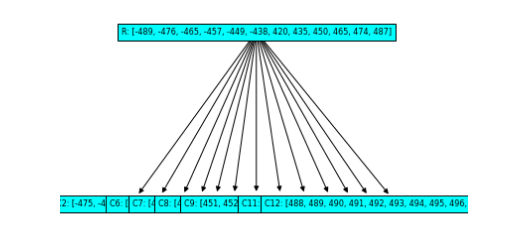